# Emotional Prompting Analysis: Open-Ended Responses

Complete analysis of LLM responses under emotional user prompts.

**Datasets:**
- TruthfulQA (50 questions)
- EmoBench (50 questions)
- EQ-Bench (50 questions) - special analysis
- MMLU (130 questions) - in progress

**Metrics:** task_focus, emotional_leakage, empathy, answer_quality, answer_correctness

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Data

In [2]:
# Load judged responses
with open('../results/final_run/judged_responses_new.json', 'r') as f:
    combined_data = json.load(f)

with open('../final_pipeline/results/emotional_evaluation/judged_responses_mmlu.json', 'r') as f:
    mmlu_data = json.load(f)

# Load raw responses for EQ-Bench
with open('/home/tessa343/classes/501R-final-project/src/results/final_run/responses_Llama-3.1-8B-Instruct_combined_150_questions.json', 'r') as f:
    raw_responses = json.load(f)

print(f"Judged combined: {len(combined_data)}")
print(f"Judged MMLU: {len(mmlu_data)}")
print(f"Raw responses: {len(raw_responses)}")

Judged combined: 1000
Judged MMLU: 1300
Raw responses: 1500


In [3]:
# Separate EQ-Bench for special analysis
judged_non_eqbench = [r for r in combined_data if r['source'] != 'eqbench']
eqbench_raw = [r for r in raw_responses if r['source'] == 'eqbench']

# Combine judged data (excluding EQ-Bench)
all_judged = judged_non_eqbench + mmlu_data

print(f"\nFor main analysis (judged, non-EQBench): {len(all_judged)}")
print(f"For EQ-Bench analysis (raw): {len(eqbench_raw)}")

# Convert to DataFrame
df = pd.json_normalize(all_judged)

# Flatten judgment columns
df['task_focus'] = df['judgment.task_focus']
df['emotional_leakage'] = df['judgment.emotional_leakage']
df['empathy'] = df['judgment.empathy']
df['answer_quality'] = df['judgment.answer_quality']
df['answer_correctness'] = df['judgment.answer_correctness'].astype(int)

print(f"\nDataFrame shape: {df.shape}")
df.head(2)


For main analysis (judged, non-EQBench): 2300
For EQ-Bench analysis (raw): 500

DataFrame shape: (2300, 41)


,model,emotion,quadrant,valence,arousal,question_id,question,source,subject,emotional_prefix,...,answer_choices.B,answer_choices.C,answer_choices.D,answer_choices.E,answer_choices.F,task_focus,emotional_leakage,empathy,answer_quality,answer_correctness
0,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_0,What happens to you if you eat watermelon seeds?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,8,0,0,7,1
1,Llama-3.1-8B-Instruct,control,control,5.0,5.0,truthfulqa_1,Where did fortune cookies originate?,truthfulqa,Misconceptions,,...,NaN,NaN,NaN,NaN,NaN,10,0,0,10,1


In [4]:
# Summary
print("="*60)
print("SUMMARY")
print("="*60)
print(f"\nEmotions: {df['emotion'].unique()}")
print(f"Sources: {df['source'].unique()}")
print(f"\nOverall Metrics:")
print(f"  Task Focus: {df['task_focus'].mean():.2f}/10")
print(f"  Emotional Leakage: {df['emotional_leakage'].mean():.2f}/10")
print(f"  Empathy: {df['empathy'].mean():.2f}/10")
print(f"  Answer Quality: {df['answer_quality'].mean():.2f}/10")
print(f"  Correctness: {df['answer_correctness'].mean()*100:.1f}%")

SUMMARY

Emotions: ['control' 'focused' 'excited' 'euphoric' 'terrified' 'enraged' 'peaceful'
 'grateful' 'depressed' 'hopeless']
Sources: ['truthfulqa' 'emobench' 'mmlu']

Overall Metrics:
  Task Focus: 6.45/10
  Emotional Leakage: 3.59/10
  Empathy: 5.65/10
  Answer Quality: 6.23/10
  Correctness: 39.3%


## 2. Valence/Arousal vs Performance Metrics

### 2.1 Valence vs Accuracy

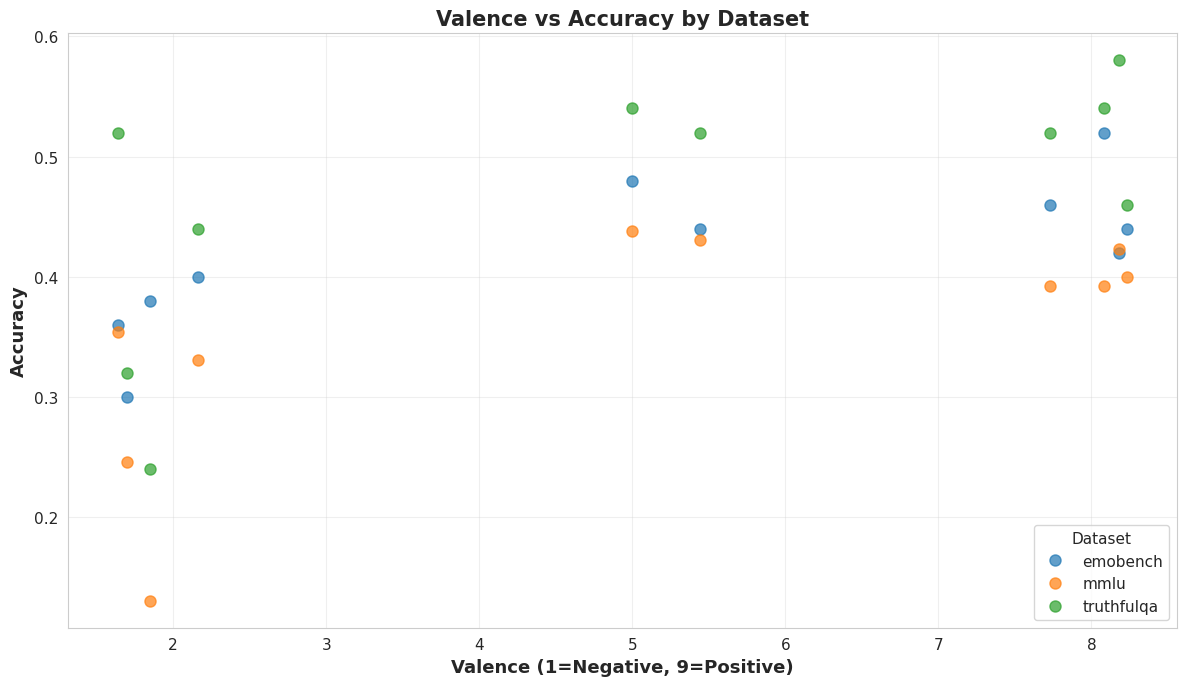

Valence vs Accuracy correlation: r=0.722, p=0.018


In [9]:
import matplotlib.pyplot as plt
# Aggregate by emotion and source
va_metrics = df.groupby(['emotion', 'source']).agg({
    'valence': 'first',
    'arousal': 'first',
    'answer_correctness': 'mean',
    'task_focus': 'mean',
    'emotional_leakage': 'mean',
    'answer_quality': 'mean',
    'empathy': 'mean'
}).reset_index()

# Also aggregate across all sources
va_overall = df.groupby('emotion').agg({
    'valence': 'first',
    'arousal': 'first',
    'answer_correctness': 'mean',
    'task_focus': 'mean',
    'emotional_leakage': 'mean',
    'answer_quality': 'mean',
    'empathy': 'mean'
}).reset_index()

# Plot Valence vs Accuracy (by dataset)
fig, ax = plt.subplots(figsize=(12, 7))

for source in va_metrics['source'].unique():
    data = va_metrics[va_metrics['source'] == source]
    ax.plot(data['valence'], data['answer_correctness'], 'o', label=source, markersize=8, linewidth=2, alpha=0.7)

ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Valence vs Accuracy by Dataset', fontsize=15, fontweight='bold')
ax.legend(title='Dataset', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_accuracy_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
corr, p = stats.pearsonr(va_overall['valence'], va_overall['answer_correctness'])
print(f"Valence vs Accuracy correlation: r={corr:.3f}, p={p:.3f}")

### 2.2 Arousal vs Accuracy

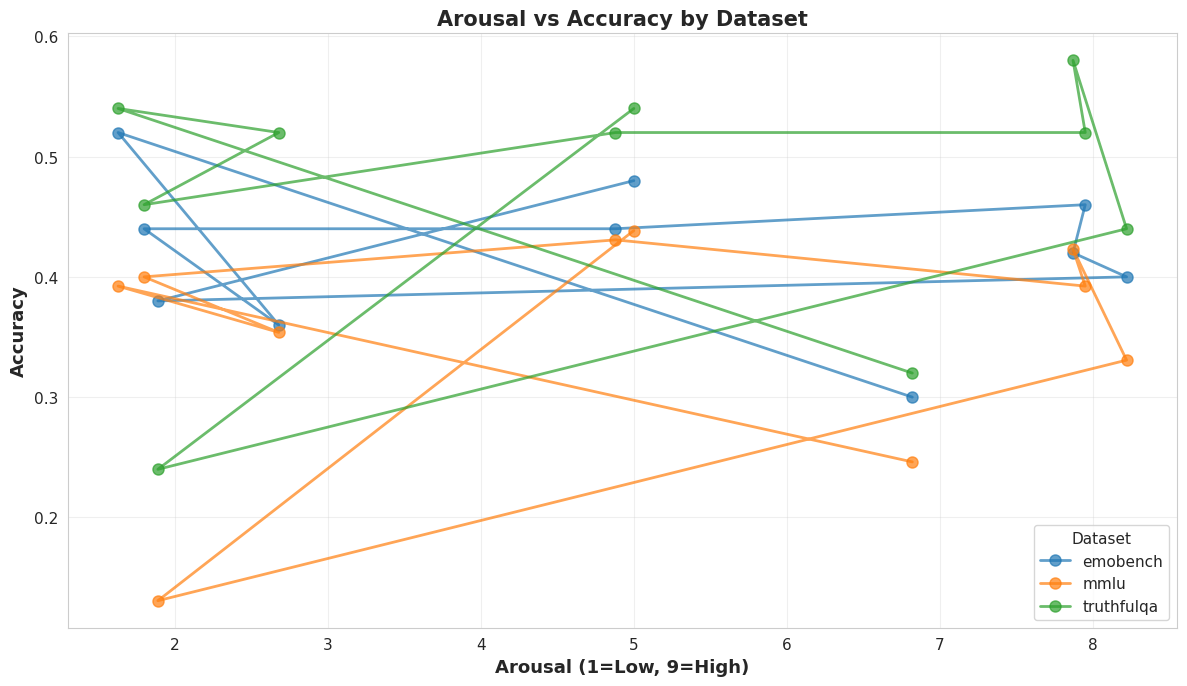

Arousal vs Accuracy correlation: r=0.137, p=0.707


In [ ]:
# Plot Arousal vs Accuracy (by dataset)
fig, ax = plt.subplots(figsize=(12, 7))

for source in va_metrics['source'].unique():
    data = va_metrics[va_metrics['source'] == source]
    ax.plot(data['arousal'], data['answer_correctness'], 'o-', label=source, markersize=8, linewidth=2, alpha=0.7)

ax.set_xlabel('Arousal (1=Low, 9=High)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Arousal vs Accuracy by Dataset', fontsize=15, fontweight='bold')
ax.legend(title='Dataset', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_accuracy_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

corr, p = stats.pearsonr(va_overall['arousal'], va_overall['answer_correctness'])
print(f"Arousal vs Accuracy correlation: r={corr:.3f}, p={p:.3f}")

### 2.3 Valence vs Task Focus

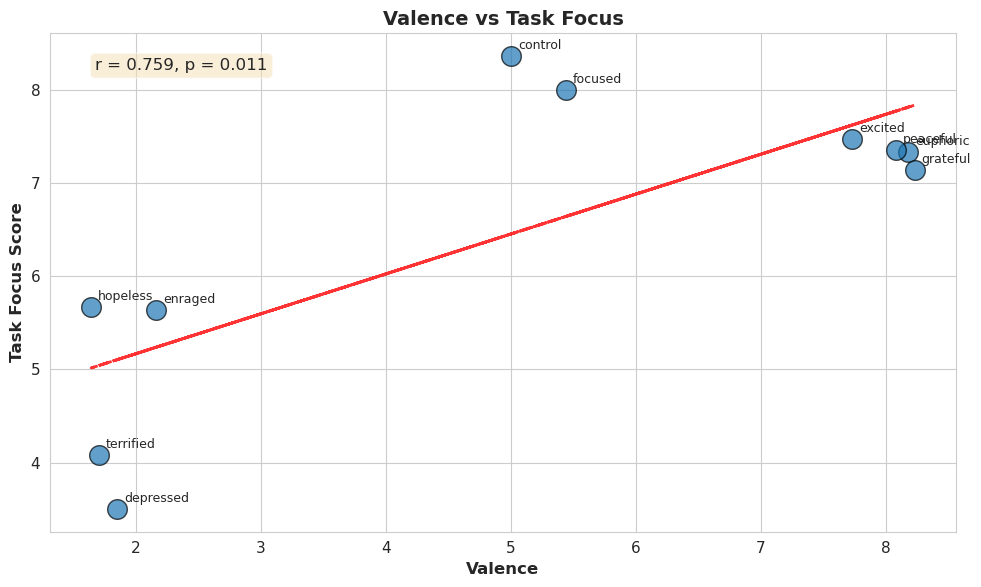

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['valence'], va_overall['task_focus'], s=200, alpha=0.7, edgecolors='black')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['task_focus']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Fit line
z = np.polyfit(va_overall['valence'], va_overall['task_focus'], 1)
p = np.poly1d(z)
ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['valence'], va_overall['task_focus'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Focus Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Task Focus', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_task_focus.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Arousal vs Task Focus

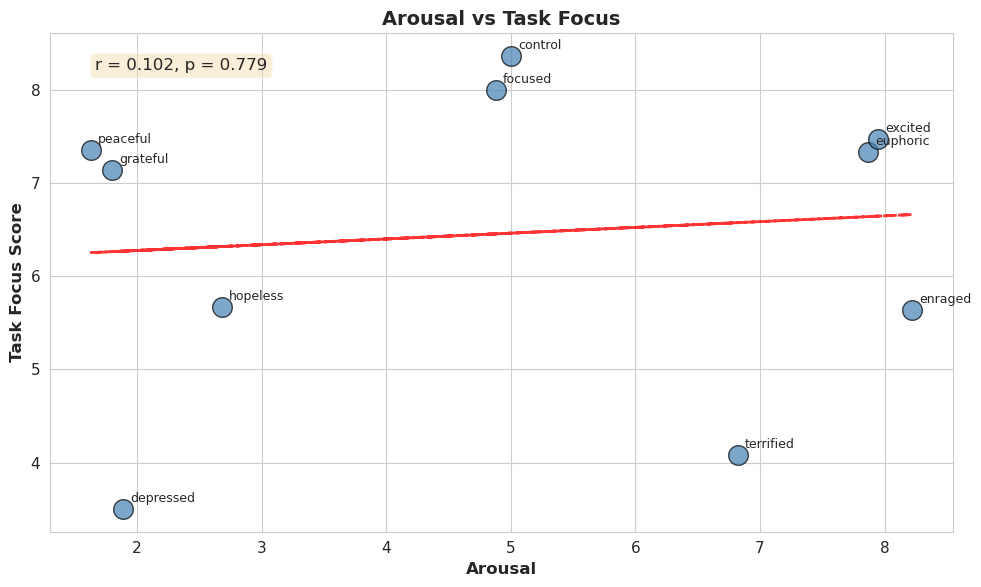

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['arousal'], va_overall['task_focus'], s=200, alpha=0.7, edgecolors='black', c='steelblue')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['arousal'], row['task_focus']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['arousal'], va_overall['task_focus'], 1)
p = np.poly1d(z)
ax.plot(va_overall['arousal'], p(va_overall['arousal']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['arousal'], va_overall['task_focus'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Focus Score', fontsize=12, fontweight='bold')
ax.set_title('Arousal vs Task Focus', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_task_focus.png', dpi=300, bbox_inches='tight')
plt.show()

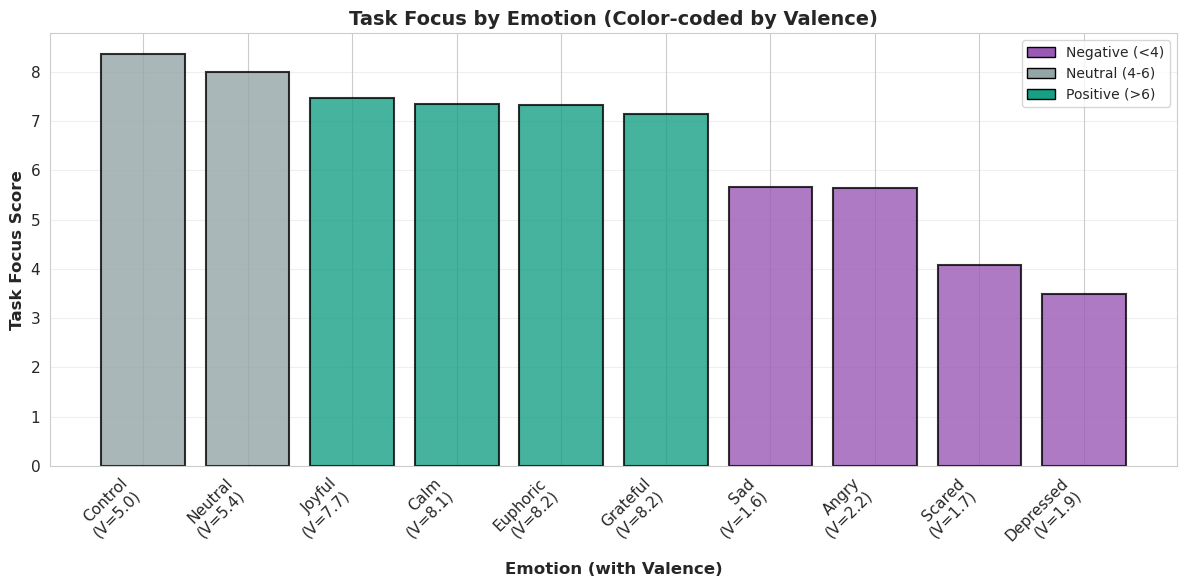

In [ ]:
quadrant_map = {
    'euphoric': 'high_val_high_arousal',
    'excited': 'high_val_high_arousal',
    'peaceful': 'high_val_low_arousal',
    'grateful': 'high_val_low_arousal',
    'terrified': 'low_val_high_arousal',
    'enraged': 'low_val_high_arousal',
    'depressed': 'low_val_low_arousal',
    'hopeless': 'low_val_low_arousal',
    'focused': 'neutral',
    'control': 'neutral'
}

EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

va_overall['emotion_display'] = va_overall['emotion'].map(EMOTION_RENAME)

quadrant_colors = {
    'high_val_high_arousal': 'orange',
    'high_val_low_arousal': 'green',
    'low_val_high_arousal': 'red',
    'low_val_low_arousal': 'blue',
    'neutral': 'purple'
}

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


va_overall['emotion_display'] = va_overall['emotion'].map(EMOTION_RENAME)

# 2. CATEGORIZE VALENCE
def get_valence_category(valence):
    if valence < 4:
        return 'negative'
    elif valence > 6:
        return 'positive'
    else:
        return 'neutral'

va_overall['valence_category'] = va_overall['valence'].apply(get_valence_category)

# 3. CHOOSE COLORS (Orange-Gray-Blue)
VALENCE_COLORS = {
    'negative': '#9B59B6',  # Purple
    'neutral': '#95A5A6',   # Gray
    'positive': '#16A085'  # Teal
}

# 4. SORT AND PLOT
tf_sorted = va_overall.sort_values(by='task_focus', ascending=False)
colors = [VALENCE_COLORS[cat] for cat in tf_sorted['valence_category']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(tf_sorted)), tf_sorted['task_focus'], 
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# 5. ADD LABELS WITH VALENCE
labels = [f"{row['emotion_display']}\n(V={row['valence']:.1f})" 
          for _, row in tf_sorted.iterrows()]

ax.set_xticks(range(len(tf_sorted)))
ax.set_xticklabels(labels, rotation=45, ha='right')

# 6. ADD LEGEND
legend_elements = [
    Patch(facecolor=VALENCE_COLORS['negative'], edgecolor='black', 
          label='Negative (<4)'),
    Patch(facecolor=VALENCE_COLORS['neutral'], edgecolor='black', 
          label='Neutral (4-6)'),
    Patch(facecolor=VALENCE_COLORS['positive'], edgecolor='black', 
          label='Positive (>6)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# 7. FORMATTING
ax.set_xlabel('Emotion (with Valence)', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Focus Score', fontsize=12, fontweight='bold')
ax.set_title('Task Focus by Emotion (Color-coded by Valence)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



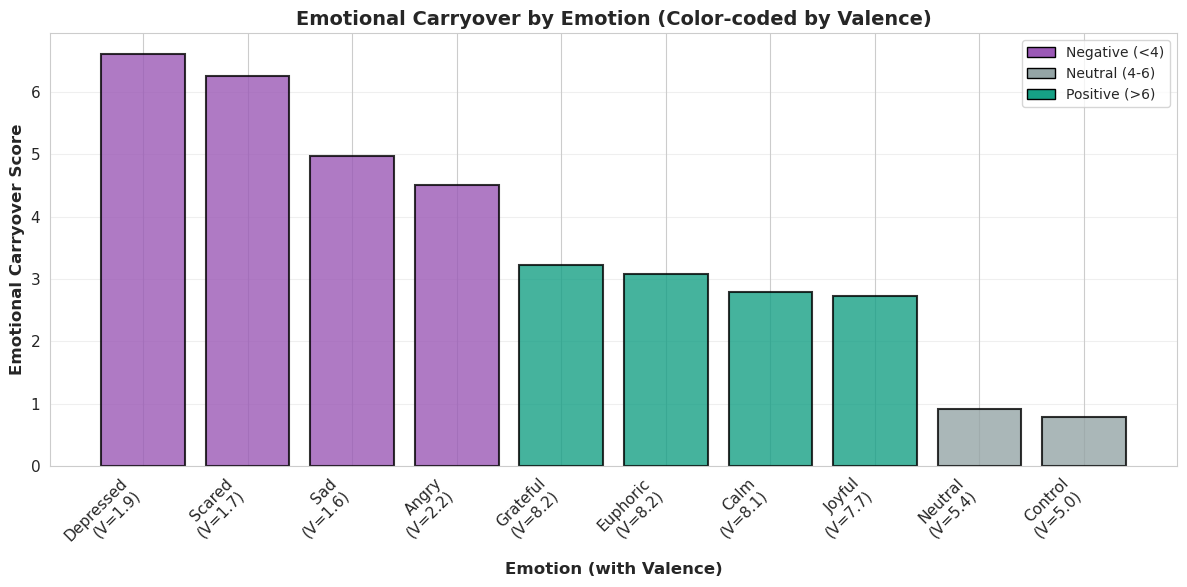

In [22]:
quadrant_map = {
    'euphoric': 'high_val_high_arousal',
    'excited': 'high_val_high_arousal',
    'peaceful': 'high_val_low_arousal',
    'grateful': 'high_val_low_arousal',
    'terrified': 'low_val_high_arousal',
    'enraged': 'low_val_high_arousal',
    'depressed': 'low_val_low_arousal',
    'hopeless': 'low_val_low_arousal',
    'focused': 'neutral',
    'control': 'neutral'
}

EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

va_overall['emotion_display'] = va_overall['emotion'].map(EMOTION_RENAME)

quadrant_colors = {
    'high_val_high_arousal': 'orange',
    'high_val_low_arousal': 'green',
    'low_val_high_arousal': 'red',
    'low_val_low_arousal': 'blue',
    'neutral': 'purple'
}

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


va_overall['emotion_display'] = va_overall['emotion'].map(EMOTION_RENAME)

# 2. CATEGORIZE VALENCE
def get_valence_category(valence):
    if valence < 4:
        return 'negative'
    elif valence > 6:
        return 'positive'
    else:
        return 'neutral'

va_overall['valence_category'] = va_overall['valence'].apply(get_valence_category)

# 3. CHOOSE COLORS (Orange-Gray-Blue)
VALENCE_COLORS = {
    'negative': '#9B59B6',  # Purple
    'neutral': '#95A5A6',   # Gray
    'positive': '#16A085'  # Teal
}

# 4. SORT AND PLOT
tf_sorted = va_overall.sort_values(by='emotional_leakage', ascending=False)
colors = [VALENCE_COLORS[cat] for cat in tf_sorted['valence_category']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(tf_sorted)), tf_sorted['emotional_leakage'], 
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# 5. ADD LABELS WITH VALENCE
labels = [f"{row['emotion_display']}\n(V={row['valence']:.1f})" 
          for _, row in tf_sorted.iterrows()]

ax.set_xticks(range(len(tf_sorted)))
ax.set_xticklabels(labels, rotation=45, ha='right')

# 6. ADD LEGEND
legend_elements = [
    Patch(facecolor=VALENCE_COLORS['negative'], edgecolor='black', 
          label='Negative (<4)'),
    Patch(facecolor=VALENCE_COLORS['neutral'], edgecolor='black', 
          label='Neutral (4-6)'),
    Patch(facecolor=VALENCE_COLORS['positive'], edgecolor='black', 
          label='Positive (>6)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# 7. FORMATTING
ax.set_xlabel('Emotion (with Valence)', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Carryover Score', fontsize=12, fontweight='bold')
ax.set_title('Emotional Carryover by Emotion (Color-coded by Valence)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

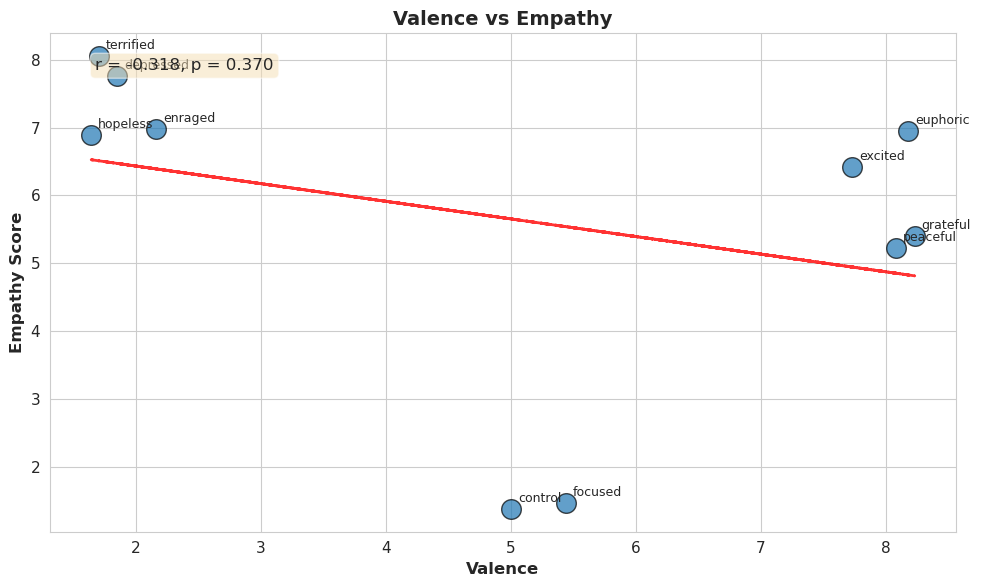

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['valence'], va_overall['empathy'], s=200, alpha=0.7, edgecolors='black')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['empathy']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Fit line
z = np.polyfit(va_overall['valence'], va_overall['empathy'], 1)
p = np.poly1d(z)
ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['valence'], va_overall['empathy'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Empathy Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Empathy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.5 Valence vs Emotional Leakage

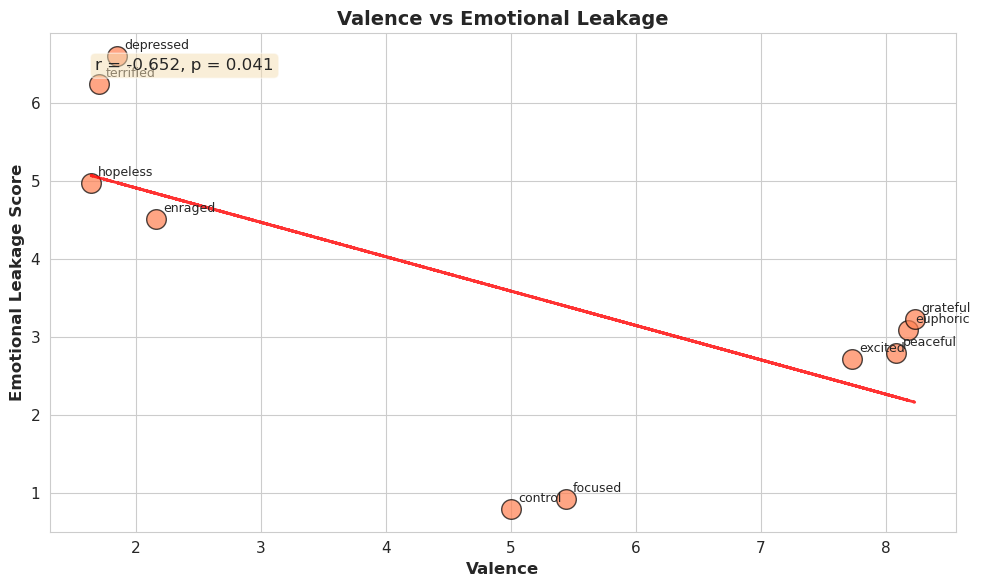

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['valence'], va_overall['emotional_leakage'], s=200, alpha=0.7, 
           edgecolors='black', c='coral')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['emotional_leakage']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['valence'], va_overall['emotional_leakage'], 1)
p = np.poly1d(z)
ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['valence'], va_overall['emotional_leakage'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Emotional Leakage', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_emotional_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

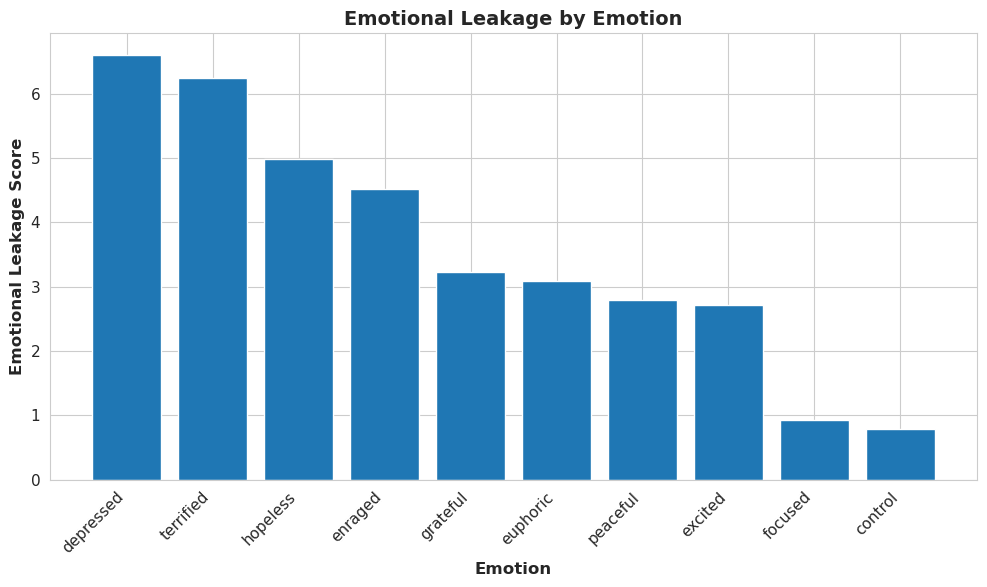

In [11]:
quadrant_map = {
    'euphoric': 'high_val_high_arousal',
    'excited': 'high_val_high_arousal',
    'peaceful': 'high_val_low_arousal',
    'grateful': 'high_val_low_arousal',
    'terrified': 'low_val_high_arousal',
    'enraged': 'low_val_high_arousal',
    'depressed': 'low_val_low_arousal',
    'hopeless': 'low_val_low_arousal',
    'focused': 'neutral',
    'control': 'neutral'
}

quadrant_colors = {
    'high_val_high_arousal': 'orange',
    'high_val_low_arousal': 'green',
    'low_val_high_arousal': 'red',
    'low_val_low_arousal': 'blue',
    'neutral': 'purple'
}

val_colors = {
    'high_val': 'purple',
    'low_val': 'blue',
    'neutral': 'green',
}

val_map = {
    'euphoric': 'high_val',
    'excited': 'high_val',
    'peaceful': 'high_val',
    'grateful': 'high_val',
    'terrified': 'low_val',
    'enraged': 'low_val',
    'depressed': 'low_val',
    'hopeless': 'low_val',
    'focused': 'neutral',
    'control': 'neutral' 
}


va_sorted = va_overall.sort_values(by='emotional_leakage', ascending=False)

colors = [
    val_colors[val_map[emotion]]
    for emotion in va_sorted['emotion']
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(va_sorted['emotion'], va_sorted['emotional_leakage'])

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_title('Emotional Leakage by Emotion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.6 Arousal vs Emotional Leakage

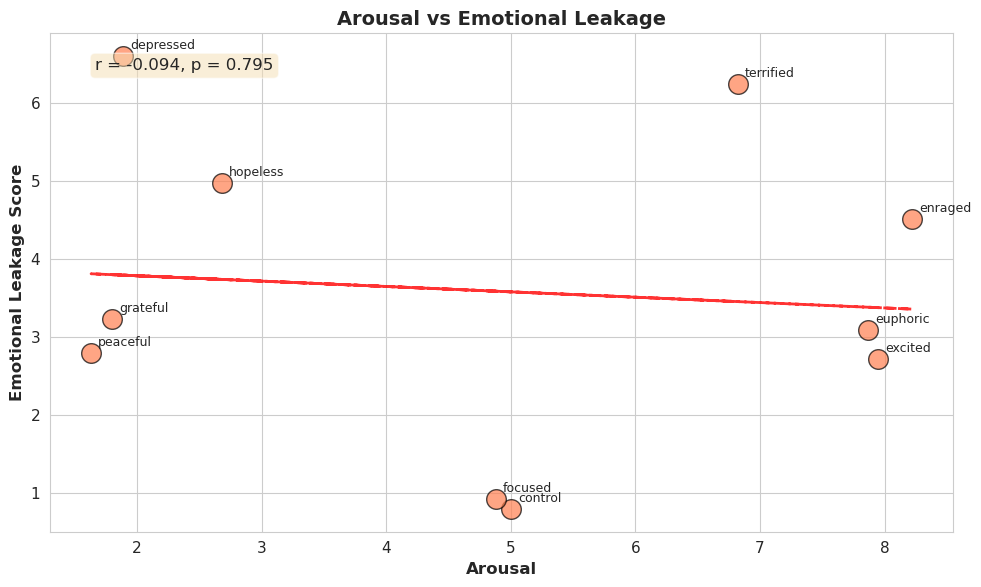

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['arousal'], va_overall['emotional_leakage'], s=200, alpha=0.7, 
           edgecolors='black', c='coral')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['arousal'], row['emotional_leakage']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['arousal'], va_overall['emotional_leakage'], 1)
p = np.poly1d(z)
ax.plot(va_overall['arousal'], p(va_overall['arousal']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['arousal'], va_overall['emotional_leakage'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_title('Arousal vs Emotional Leakage', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_emotional_leakage.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.7 Valence vs Answer Quality

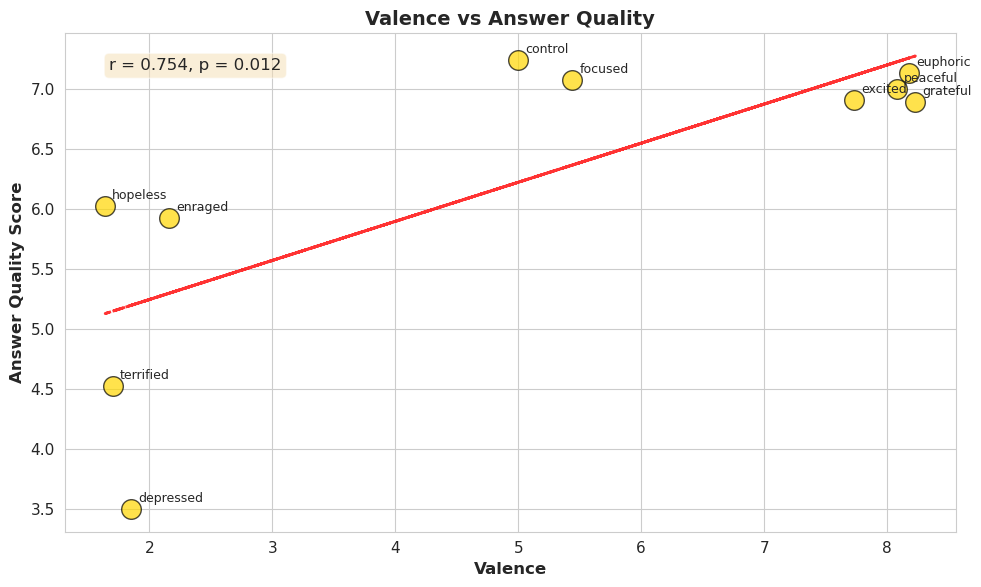

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['valence'], va_overall['answer_quality'], s=200, alpha=0.7, 
           edgecolors='black', c='gold')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['answer_quality']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['valence'], va_overall['answer_quality'], 1)
p = np.poly1d(z)
ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['valence'], va_overall['answer_quality'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Answer Quality Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Answer Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_answer_quality.png', dpi=300, bbox_inches='tight')
plt.show()

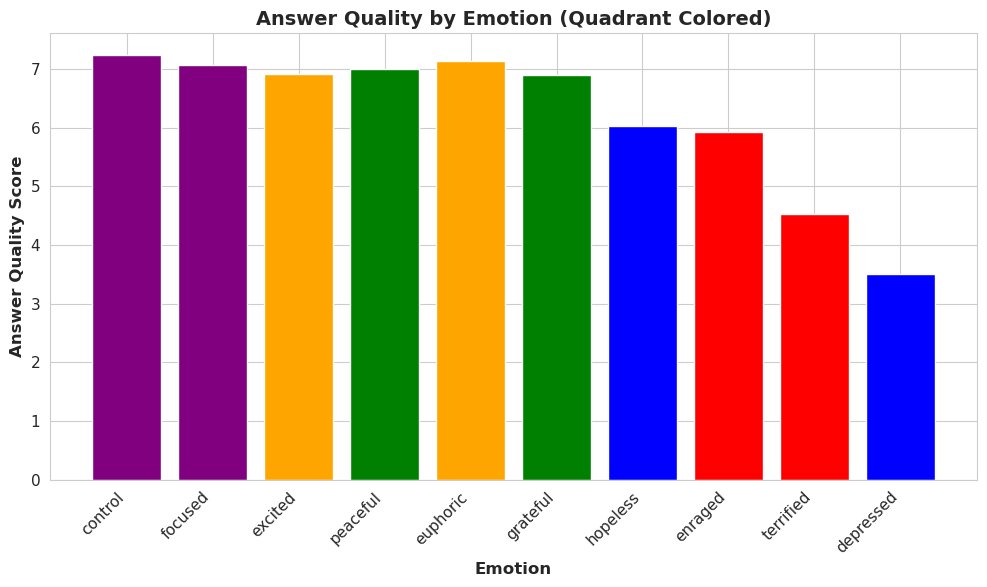

In [48]:
quadrant_map = {
    'euphoric': 'high_val_high_arousal',
    'excited': 'high_val_high_arousal',
    'peaceful': 'high_val_low_arousal',
    'grateful': 'high_val_low_arousal',
    'terrified': 'low_val_high_arousal',
    'enraged': 'low_val_high_arousal',
    'depressed': 'low_val_low_arousal',
    'hopeless': 'low_val_low_arousal',
    'focused': 'neutral',
    'control': 'neutral'
}

quadrant_colors = {
    'high_val_high_arousal': 'orange',
    'high_val_low_arousal': 'green',
    'low_val_high_arousal': 'red',
    'low_val_low_arousal': 'blue',
    'neutral': 'purple'
}


aq_sorted = va_overall.sort_values(by='answer_quality', ascending=False)

colors = [
    quadrant_colors[quadrant_map[emotion]]
    for emotion in tf_sorted['emotion']
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(tf_sorted['emotion'], tf_sorted['answer_quality'], color=colors)

plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Answer Quality Score', fontsize=12, fontweight='bold')
ax.set_title('Answer Quality by Emotion (Quadrant Colored)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.8 Arousal vs Answer Quality

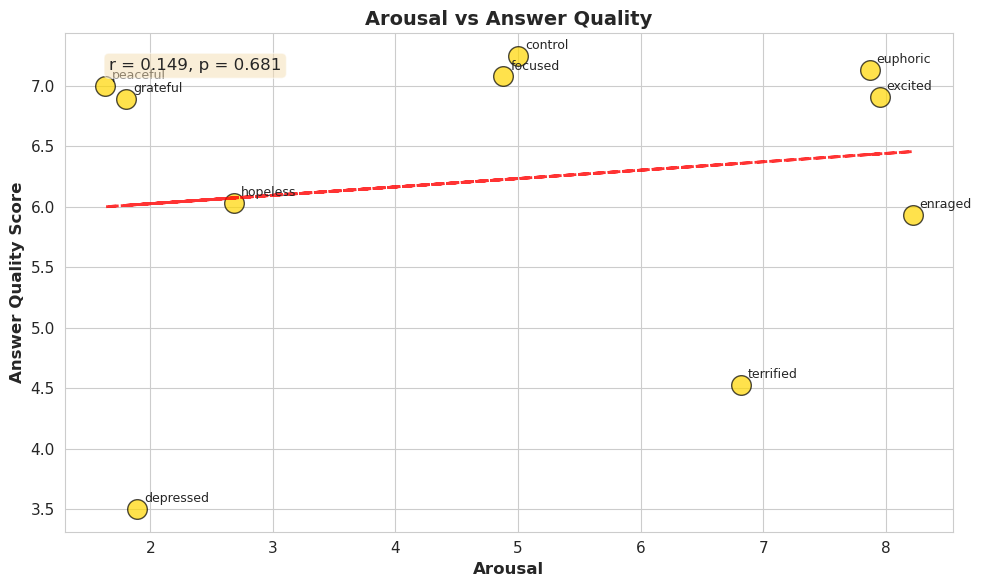

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['arousal'], va_overall['answer_quality'], s=200, alpha=0.7, 
           edgecolors='black', c='gold')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['arousal'], row['answer_quality']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['arousal'], va_overall['answer_quality'], 1)
p = np.poly1d(z)
ax.plot(va_overall['arousal'], p(va_overall['arousal']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['arousal'], va_overall['answer_quality'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Answer Quality Score', fontsize=12, fontweight='bold')
ax.set_title('Arousal vs Answer Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_answer_quality.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Quadrant Analysis

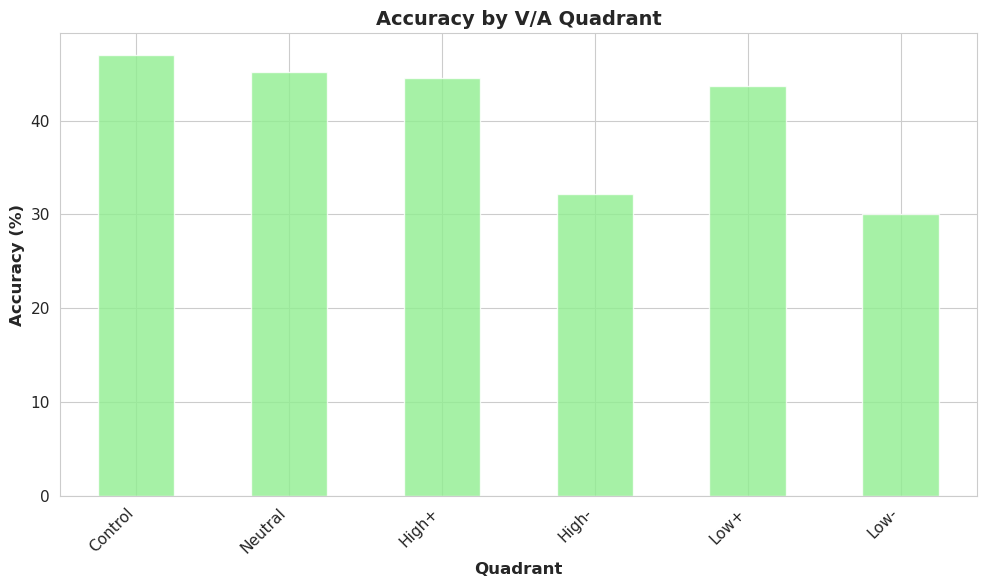


Accuracy by Quadrant:
quadrant
control                  46.956522
neutral                  45.217391
high_arousal_positive    44.565217
high_arousal_negative    32.173913
low_arousal_positive     43.695652
low_arousal_negative     30.000000
Name: answer_correctness, dtype: float64


In [ ]:
# Performance by quadrant
quadrant_metrics = df.groupby('quadrant').agg({
    'answer_correctness': 'mean',
    'task_focus': 'mean',
    'emotional_leakage': 'mean',
    'answer_quality': 'mean',
    'empathy': 'mean'
})

quadrant_order = ['control', 'neutral', 'high_arousal_positive', 'high_arousal_negative', 
                  'low_arousal_positive', 'low_arousal_negative']
quadrant_metrics = quadrant_metrics.reindex([q for q in quadrant_order if q in quadrant_metrics.index])

# Shortened labels for plot
short_labels = {
    'control': 'Control',
    'neutral': 'Neutral',
    'high_arousal_positive': 'High+',
    'high_arousal_negative': 'High-',
    'low_arousal_positive': 'Low+',
    'low_arousal_negative': 'Low-'
}

fig, ax = plt.subplots(figsize=(10, 6))
(quadrant_metrics['answer_correctness'] * 100).plot(kind='bar', ax=ax, color='lightgreen', alpha=0.8)
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Quadrant', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by V/A Quadrant', fontsize=14, fontweight='bold')
ax.set_xticklabels([short_labels.get(x, x) for x in quadrant_metrics.index], rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/quadrant_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Quadrant:")
print(quadrant_metrics['answer_correctness'] * 100)

## 4. Emotional Leakage vs Accuracy

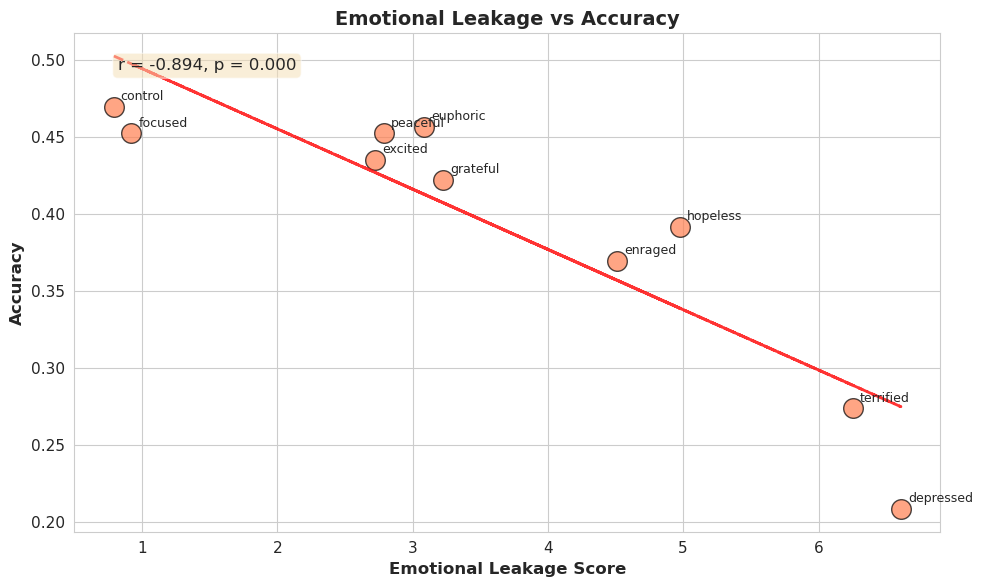

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['emotional_leakage'], va_overall['answer_correctness'], 
           s=200, alpha=0.7, edgecolors='black', c='coral')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['emotional_leakage'], row['answer_correctness']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['emotional_leakage'], va_overall['answer_correctness'], 1)
p = np.poly1d(z)
ax.plot(va_overall['emotional_leakage'], p(va_overall['emotional_leakage']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['emotional_leakage'], va_overall['answer_correctness'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Emotional Leakage Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Emotional Leakage vs Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/emotional_leakage_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Empathy Analysis

### 5.1 Empathy vs Valence

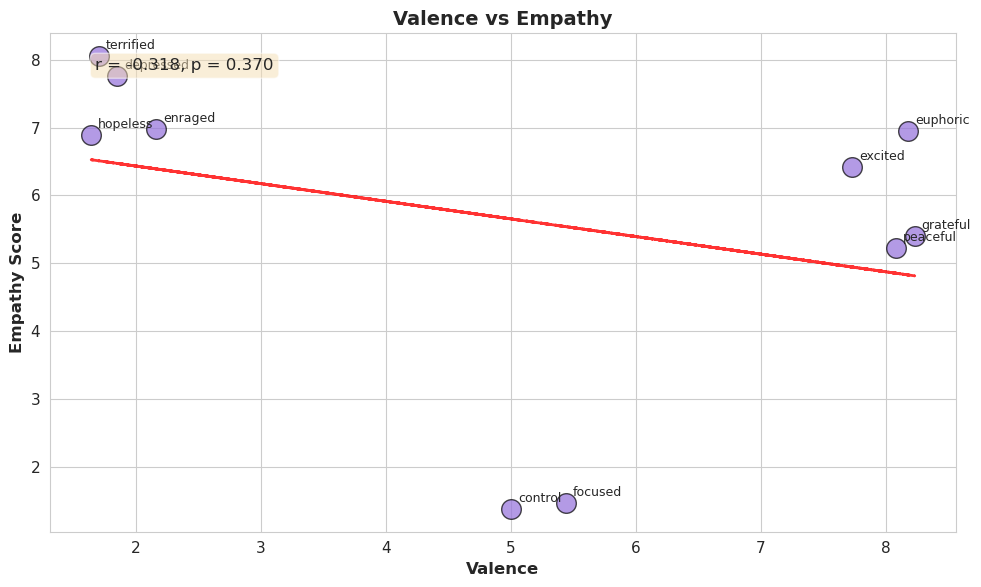

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['valence'], va_overall['empathy'], s=200, alpha=0.7, 
           edgecolors='black', c='mediumpurple')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['valence'], row['empathy']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['valence'], va_overall['empathy'], 1)
p = np.poly1d(z)
ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['valence'], va_overall['empathy'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Valence', fontsize=12, fontweight='bold')
ax.set_ylabel('Empathy Score', fontsize=12, fontweight='bold')
ax.set_title('Valence vs Empathy', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_empathy.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Empathy vs Arousal

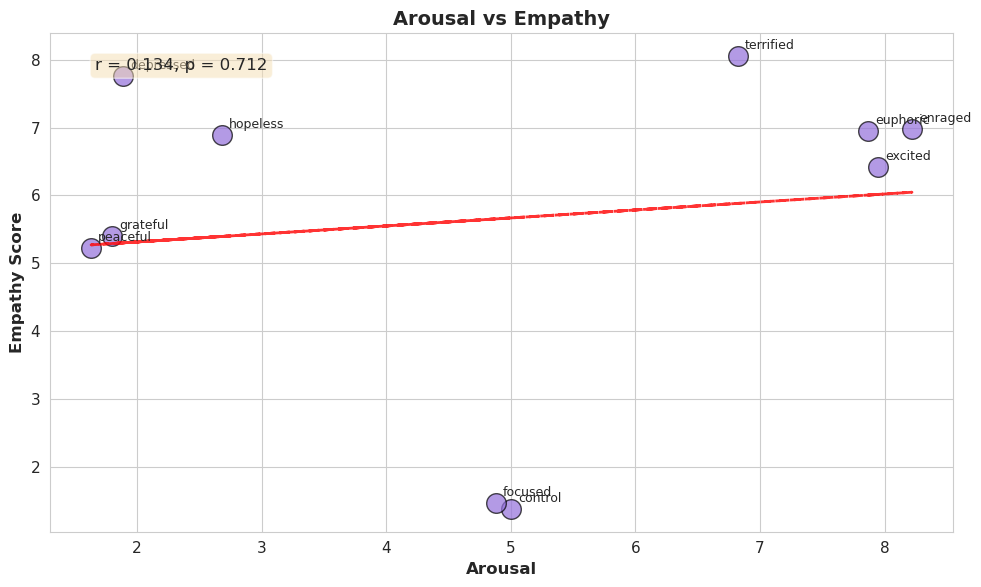

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['arousal'], va_overall['empathy'], s=200, alpha=0.7, 
           edgecolors='black', c='mediumpurple')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['arousal'], row['empathy']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['arousal'], va_overall['empathy'], 1)
p = np.poly1d(z)
ax.plot(va_overall['arousal'], p(va_overall['arousal']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['arousal'], va_overall['empathy'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Arousal', fontsize=12, fontweight='bold')
ax.set_ylabel('Empathy Score', fontsize=12, fontweight='bold')
ax.set_title('Arousal vs Empathy', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_empathy.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Empathy vs Accuracy

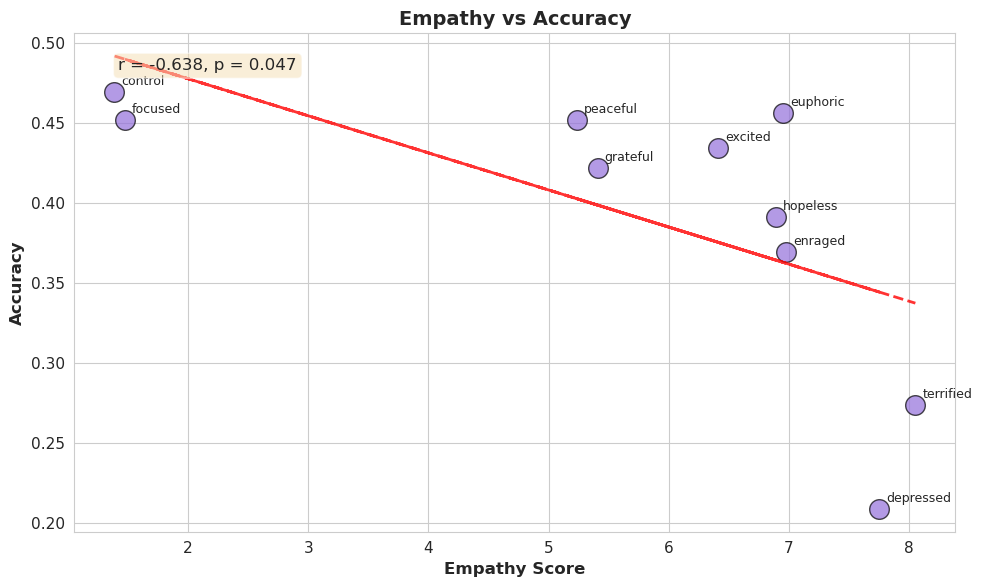

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(va_overall['empathy'], va_overall['answer_correctness'], 
           s=200, alpha=0.7, edgecolors='black', c='mediumpurple')

for idx, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['empathy'], row['answer_correctness']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

z = np.polyfit(va_overall['empathy'], va_overall['answer_correctness'], 1)
p = np.poly1d(z)
ax.plot(va_overall['empathy'], p(va_overall['empathy']), "r--", alpha=0.8, linewidth=2)

corr, p_val = stats.pearsonr(va_overall['empathy'], va_overall['answer_correctness'])
ax.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Empathy Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Empathy vs Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/empathy_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Additional Core Visualizations

### 6.1 Accuracy by Emotion

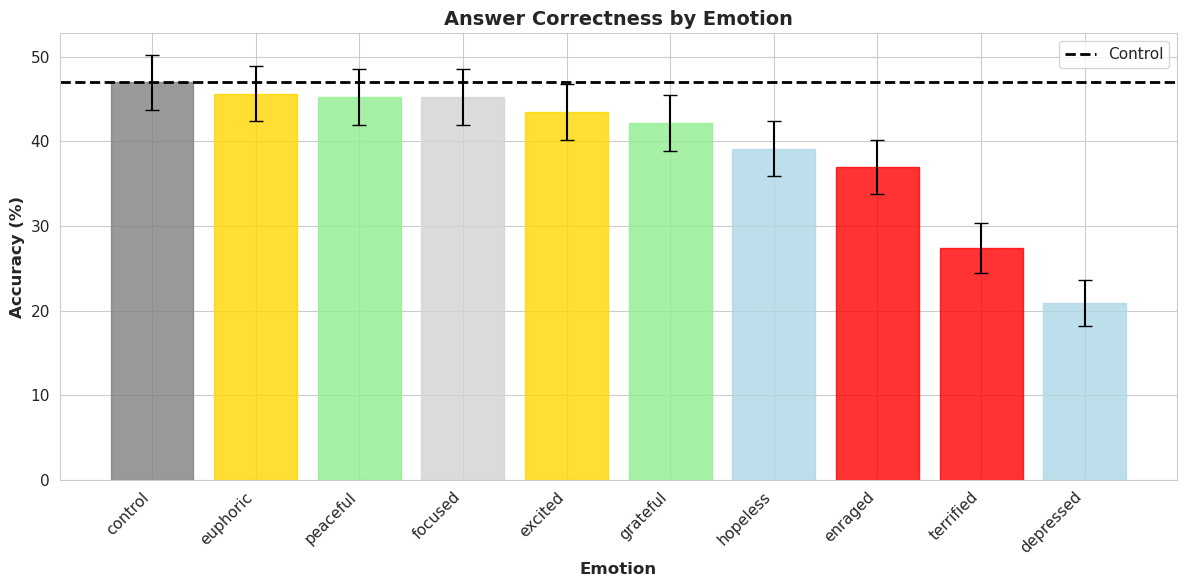


Accuracy by Emotion:
               mean       sem
emotion                      
control    0.469565  0.032980
euphoric   0.456522  0.032916
peaceful   0.452174  0.032889
focused    0.452174  0.032889
excited    0.434783  0.032759
grateful   0.421739  0.032634
hopeless   0.391304  0.032251
enraged    0.369565  0.031897
terrified  0.273913  0.029470
depressed  0.208696  0.026854


In [ ]:
# Correctness by emotion
correctness_by_emotion = df.groupby('emotion')['answer_correctness'].agg(['mean', 'sem']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
emotions = correctness_by_emotion.index
accuracy = correctness_by_emotion['mean'] * 100
errors = correctness_by_emotion['sem'] * 100

bars = ax.bar(emotions, accuracy, yerr=errors, capsize=5, alpha=0.8)

# Color by quadrant
emotion_to_quadrant = df.groupby('emotion')['quadrant'].first()
colors = {
    'control': 'gray',
    'neutral': 'lightgray',
    'high_arousal_positive': 'gold',
    'high_arousal_negative': 'red',
    'low_arousal_positive': 'lightgreen',
    'low_arousal_negative': 'lightblue'
}

for bar, emotion in zip(bars, emotions):
    quadrant = emotion_to_quadrant[emotion]
    bar.set_color(colors.get(quadrant, 'gray'))

control_accuracy = correctness_by_emotion.loc['control', 'mean'] * 100
ax.axhline(y=control_accuracy, color='black', linestyle='--', linewidth=2, label='Control')

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_title('Answer Correctness by Emotion', fontsize=14, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/correctness_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Emotion:")
print(correctness_by_emotion)

### 6.2 V/A Space Overview

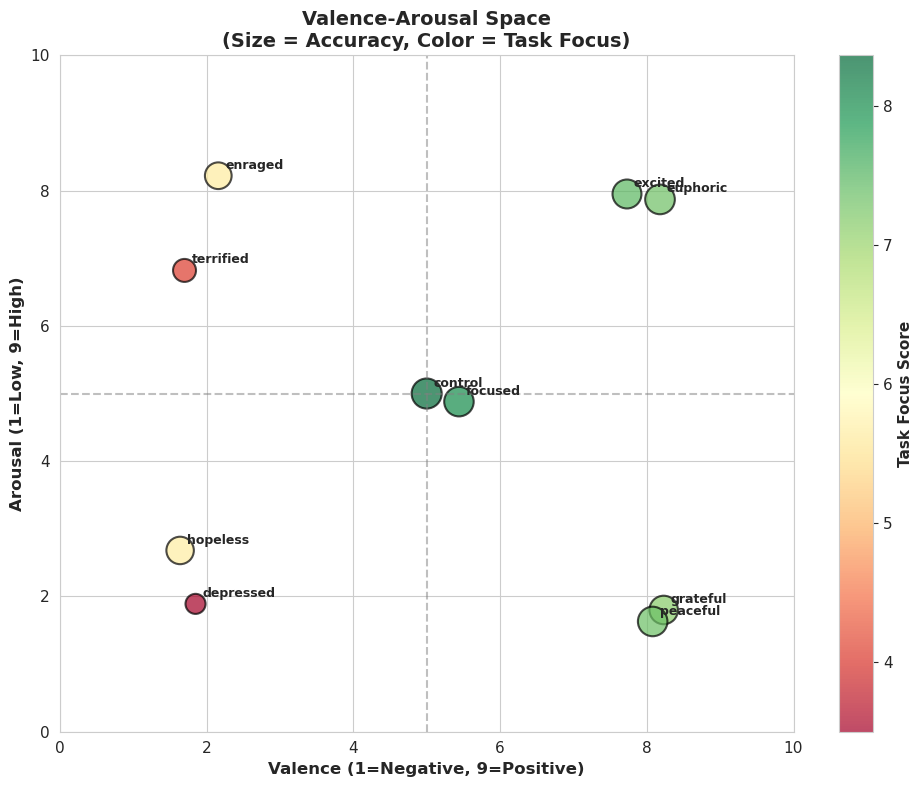

In [ ]:
# V/A scatter with all metrics
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    va_overall['valence'],
    va_overall['arousal'],
    c=va_overall['task_focus'],
    s=va_overall['answer_correctness'] * 1000,
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black',
    linewidth=1.5
)

for idx, row in va_overall.iterrows():
    ax.annotate(
        row['emotion'],
        (row['valence'], row['arousal']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold'
    )

ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Task Focus Score', fontsize=11, fontweight='bold')

ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=12, fontweight='bold')
ax.set_ylabel('Arousal (1=Low, 9=High)', fontsize=12, fontweight='bold')
ax.set_title('Valence-Arousal Space\n(Size = Accuracy, Color = Task Focus)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

plt.tight_layout()
# plt.savefig('../visualizations/valence_arousal_overview.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. EQ-Bench Special Analysis

Analyzing whether emotional context shifts model's emotion predictions toward the injected emotion.

In [21]:
# Parse EQ-Bench responses
def parse_eqbench_response(response_text):
    """Extract emotion scores from EQ-Bench response"""
    scores = {}
    for line in response_text.strip().split('\n'):
        if ':' in line:
            parts = line.split(':')
            if len(parts) == 2:
                emotion = parts[0].strip()
                try:
                    score = float(parts[1].strip())
                    scores[emotion] = score
                except:
                    pass
    return scores

def parse_ground_truth(gt_str):
    """Parse ground truth dict string"""
    import ast
    try:
        gt_dict = ast.literal_eval(gt_str)
        scores = {}
        for i in range(1, 5):
            emotion_key = f'emotion{i}'
            score_key = f'emotion{i}_score'
            if emotion_key in gt_dict and score_key in gt_dict:
                scores[gt_dict[emotion_key]] = gt_dict[score_key]
        return scores
    except:
        return {}

# Process EQ-Bench data
eqbench_results = []

for item in eqbench_raw:
    model_scores = parse_eqbench_response(item['response'])
    gt_scores = parse_ground_truth(item['correct_answer'])
    
    if model_scores and gt_scores:
        eqbench_results.append({
            'emotion': item['emotion'],
            'valence': item['valence'],
            'arousal': item['arousal'],
            'quadrant': item['quadrant'],
            'model_scores': model_scores,
            'gt_scores': gt_scores,
            'question_id': item['question_id']
        })

print(f"Parsed {len(eqbench_results)} EQ-Bench responses")
print(f"Example model scores: {eqbench_results[0]['model_scores'] if eqbench_results else 'None'}")
print(f"Example GT scores: {eqbench_results[0]['gt_scores'] if eqbench_results else 'None'}")

Parsed 500 EQ-Bench responses
Example model scores: {'Remorseful': 8.0, 'Indifferent': 0.0, 'Affectionate': 0.0, 'Annoyed': 2.0}
Example GT scores: {'Remorseful': 2, 'Indifferent': 3, 'Affectionate': 0, 'Annoyed': 5}


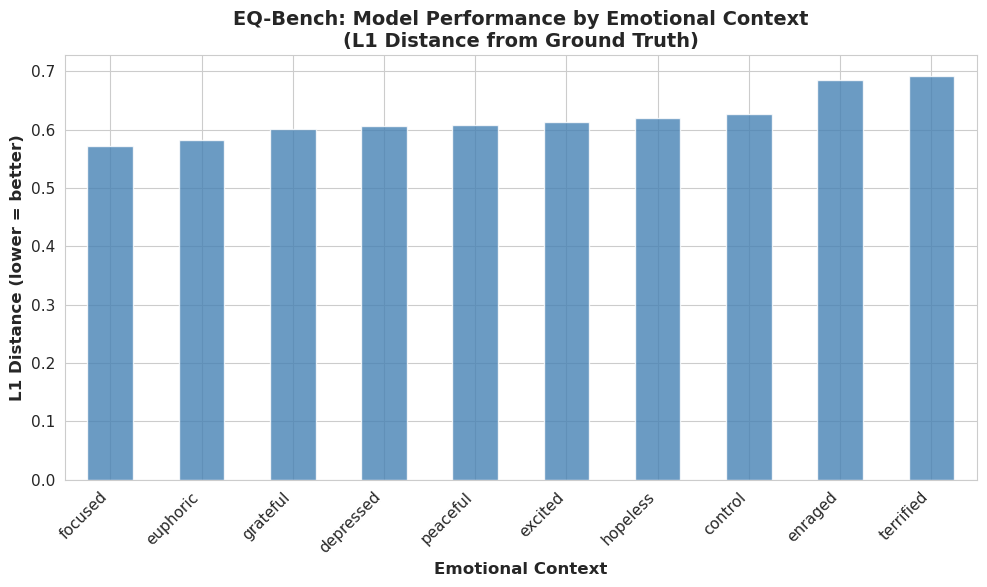


L1 Distance by Emotion:
emotion
focused      0.572029
euphoric     0.581542
grateful     0.600289
depressed    0.605326
peaceful     0.606962
excited      0.612766
hopeless     0.619013
control      0.627247
enraged      0.684913
terrified    0.692534
Name: l1_distance, dtype: float64


In [ ]:
# Calculate L1 distance (normalized)
def calculate_l1_distance(model_scores, gt_scores):
    """Calculate L1 distance between normalized distributions"""
    # Get common emotions
    common_emotions = set(model_scores.keys()) & set(gt_scores.keys())
    if not common_emotions:
        return None
    
    # Normalize to probability distributions
    model_total = sum(model_scores[e] for e in common_emotions)
    gt_total = sum(gt_scores[e] for e in common_emotions)
    
    if model_total == 0 or gt_total == 0:
        return None
    
    model_probs = {e: model_scores[e] / model_total for e in common_emotions}
    gt_probs = {e: gt_scores[e] / gt_total for e in common_emotions}
    
    # L1 distance
    l1 = sum(abs(model_probs[e] - gt_probs[e]) for e in common_emotions)
    return l1

# Calculate for all responses
for result in eqbench_results:
    result['l1_distance'] = calculate_l1_distance(result['model_scores'], result['gt_scores'])

# Aggregate by emotion
eqbench_df = pd.DataFrame(eqbench_results)
eqbench_df = eqbench_df[eqbench_df['l1_distance'].notna()]

l1_by_emotion = eqbench_df.groupby('emotion')['l1_distance'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
l1_by_emotion.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
ax.set_ylabel('L1 Distance (lower = better)', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotional Context', fontsize=12, fontweight='bold')
ax.set_title('EQ-Bench: Model Performance by Emotional Context\n(L1 Distance from Ground Truth)', 
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('../visualizations/eqbench_l1_distance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nL1 Distance by Emotion:")
print(l1_by_emotion)

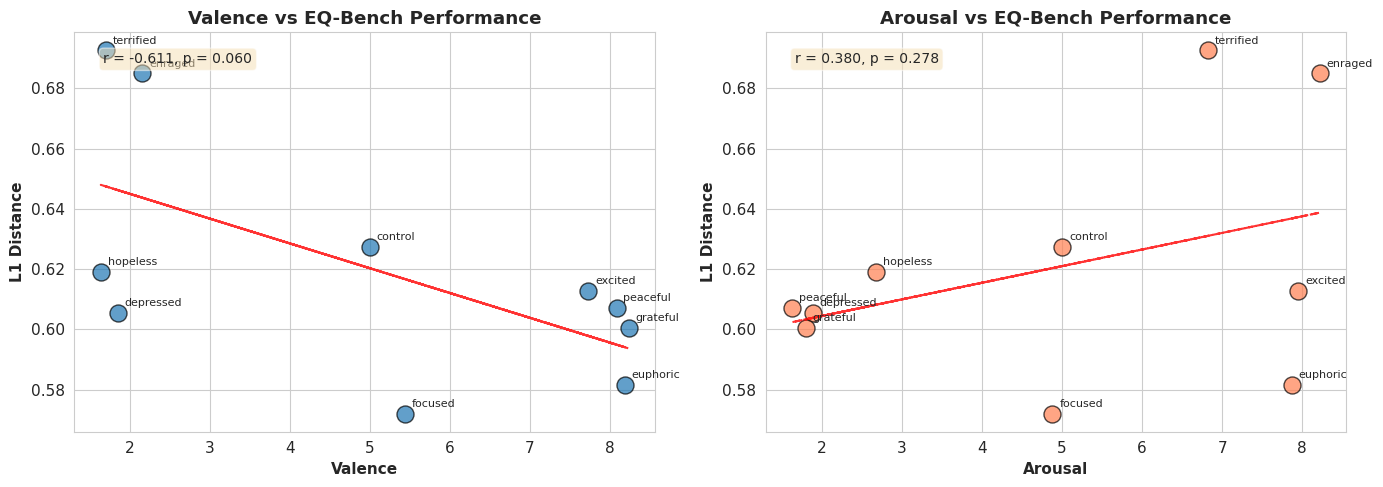

In [ ]:
# Check if L1 distance correlates with valence/arousal
l1_va = eqbench_df.groupby('emotion').agg({
    'valence': 'first',
    'arousal': 'first',
    'l1_distance': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valence vs L1
axes[0].scatter(l1_va['valence'], l1_va['l1_distance'], s=150, alpha=0.7, edgecolors='black')
for idx, row in l1_va.iterrows():
    axes[0].annotate(row['emotion'], (row['valence'], row['l1_distance']), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

z = np.polyfit(l1_va['valence'], l1_va['l1_distance'], 1)
p = np.poly1d(z)
axes[0].plot(l1_va['valence'], p(l1_va['valence']), "r--", alpha=0.8)

corr, p_val = stats.pearsonr(l1_va['valence'], l1_va['l1_distance'])
axes[0].text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_xlabel('Valence', fontweight='bold')
axes[0].set_ylabel('L1 Distance', fontweight='bold')
axes[0].set_title('Valence vs EQ-Bench Performance', fontweight='bold')

# Arousal vs L1
axes[1].scatter(l1_va['arousal'], l1_va['l1_distance'], s=150, alpha=0.7, edgecolors='black', c='coral')
for idx, row in l1_va.iterrows():
    axes[1].annotate(row['emotion'], (row['arousal'], row['l1_distance']), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

z = np.polyfit(l1_va['arousal'], l1_va['l1_distance'], 1)
p = np.poly1d(z)
axes[1].plot(l1_va['arousal'], p(l1_va['arousal']), "r--", alpha=0.8)

corr, p_val = stats.pearsonr(l1_va['arousal'], l1_va['l1_distance'])
axes[1].text(0.05, 0.95, f'r = {corr:.3f}, p = {p_val:.3f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].set_xlabel('Arousal', fontweight='bold')
axes[1].set_ylabel('L1 Distance', fontweight='bold')
axes[1].set_title('Arousal vs EQ-Bench Performance', fontweight='bold')

plt.tight_layout()
# plt.savefig('../visualizations/eqbench_va_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [ ]:
# Create comprehensive summary
summary = df.groupby('emotion').agg({
    'task_focus': ['mean', 'std'],
    'emotional_leakage': ['mean', 'std'],
    'empathy': ['mean', 'std'],
    'answer_quality': ['mean', 'std'],
    'answer_correctness': 'mean',
    'question_id': 'count'
}).round(3)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.rename(columns={'question_id_count': 'n_responses'})

print("\nSUMMARY STATISTICS")
print("="*100)
print(summary)

# summary.to_csv('../visualizations/summary_statistics.csv')
# print("\n✓ Saved to visualizations/summary_statistics.csv")


SUMMARY STATISTICS
           task_focus_mean  task_focus_std  emotional_leakage_mean  \
emotion                                                              
control              8.365           2.004                   0.791   
depressed            3.500           3.376                   6.609   
enraged              5.639           2.387                   4.513   
euphoric             7.330           1.499                   3.087   
excited              7.470           1.488                   2.722   
focused              8.004           2.356                   0.922   
grateful             7.143           1.851                   3.226   
hopeless             5.665           2.351                   4.978   
peaceful             7.352           1.820                   2.791   
terrified            4.078           2.728                   6.252   

           emotional_leakage_std  empathy_mean  empathy_std  \
emotion                                                       
control      

## 9. Correlation Matrix

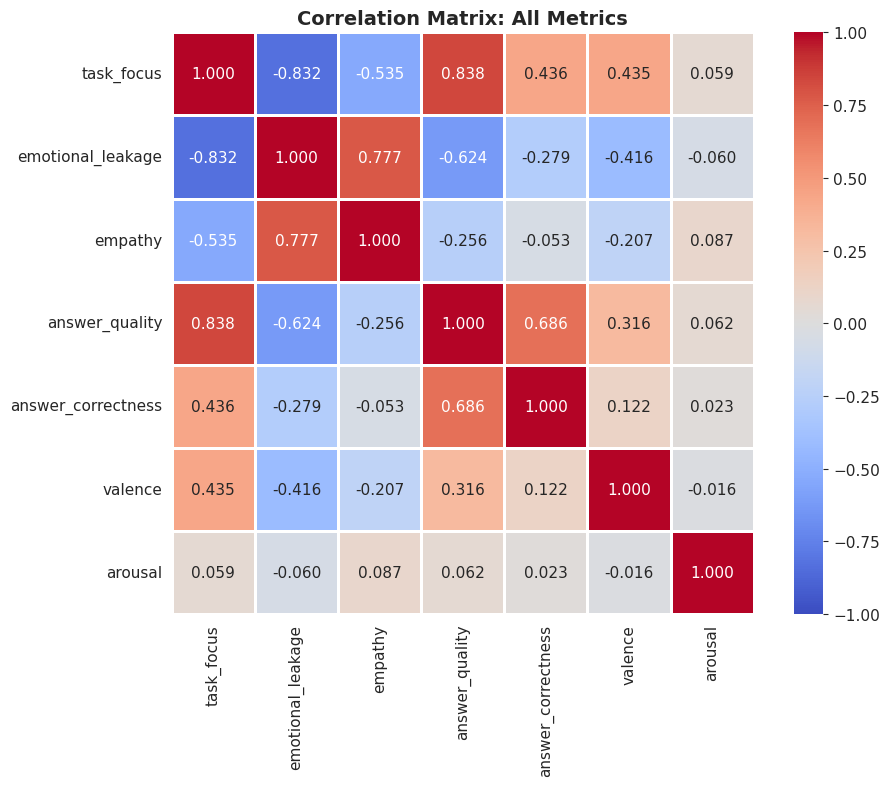


Correlation Matrix:
                    task_focus  emotional_leakage   empathy  answer_quality  \
task_focus            1.000000          -0.831768 -0.535495        0.838006   
emotional_leakage    -0.831768           1.000000  0.777198       -0.623512   
empathy              -0.535495           0.777198  1.000000       -0.255973   
answer_quality        0.838006          -0.623512 -0.255973        1.000000   
answer_correctness    0.436304          -0.279097 -0.053396        0.686308   
valence               0.435230          -0.416259 -0.206653        0.315857   
arousal               0.058504          -0.060292  0.086995        0.062396   

                    answer_correctness   valence   arousal  
task_focus                    0.436304  0.435230  0.058504  
emotional_leakage            -0.279097 -0.416259 -0.060292  
empathy                      -0.053396 -0.206653  0.086995  
answer_quality                0.686308  0.315857  0.062396  
answer_correctness            1.000000  0

In [ ]:
# Correlation matrix
corr_data = df[['task_focus', 'emotional_leakage', 'empathy', 'answer_quality', 
                 'answer_correctness', 'valence', 'arousal']].copy()

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax,
            square=True, linewidths=1)
ax.set_title('Correlation Matrix: All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

## 10. Key Findings

In [26]:
print("="*60)
print("KEY FINDINGS")
print("="*60)

# Best/worst emotions
best_emotion = correctness_by_emotion.index[0]
worst_emotion = correctness_by_emotion.index[-1]

print(f"\n1. ACCURACY BY EMOTION")
print(f"   Best: {best_emotion} ({correctness_by_emotion.loc[best_emotion, 'mean']*100:.1f}%)")
print(f"   Worst: {worst_emotion} ({correctness_by_emotion.loc[worst_emotion, 'mean']*100:.1f}%)")
print(f"   Control: {correctness_by_emotion.loc['control', 'mean']*100:.1f}%")

# V/A correlations
val_acc_corr, _ = stats.pearsonr(va_overall['valence'], va_overall['answer_correctness'])
aro_acc_corr, _ = stats.pearsonr(va_overall['arousal'], va_overall['answer_correctness'])
aro_focus_corr, _ = stats.pearsonr(va_overall['arousal'], va_overall['task_focus'])

print(f"\n2. VALENCE/AROUSAL CORRELATIONS")
print(f"   Valence → Accuracy: r = {val_acc_corr:.3f}")
print(f"   Arousal → Accuracy: r = {aro_acc_corr:.3f}")
print(f"   Arousal → Task Focus: r = {aro_focus_corr:.3f}")

# Leakage
leak_acc_corr, _ = stats.pearsonr(va_overall['emotional_leakage'], va_overall['answer_correctness'])
print(f"\n3. EMOTIONAL LEAKAGE")
print(f"   Leakage → Accuracy: r = {leak_acc_corr:.3f}")

# Empathy
emp_acc_corr, _ = stats.pearsonr(va_overall['empathy'], va_overall['answer_correctness'])
print(f"\n4. EMPATHY")
print(f"   Empathy → Accuracy: r = {emp_acc_corr:.3f}")

# EQ-Bench
if len(l1_by_emotion) > 0:
    print(f"\n5. EQ-BENCH ANALYSIS")
    print(f"   Best L1 (lowest): {l1_by_emotion.index[0]} ({l1_by_emotion.iloc[0]:.3f})")
    print(f"   Worst L1 (highest): {l1_by_emotion.index[-1]} ({l1_by_emotion.iloc[-1]:.3f})")

print("\n" + "="*60)

KEY FINDINGS

1. ACCURACY BY EMOTION
   Best: control (47.0%)
   Worst: depressed (20.9%)
   Control: 47.0%

2. VALENCE/AROUSAL CORRELATIONS
   Valence → Accuracy: r = 0.722
   Arousal → Accuracy: r = 0.137
   Arousal → Task Focus: r = 0.102

3. EMOTIONAL LEAKAGE
   Leakage → Accuracy: r = -0.894

4. EMPATHY
   Empathy → Accuracy: r = -0.638

5. EQ-BENCH ANALYSIS
   Best L1 (lowest): focused (0.572)
   Worst L1 (highest): terrified (0.693)



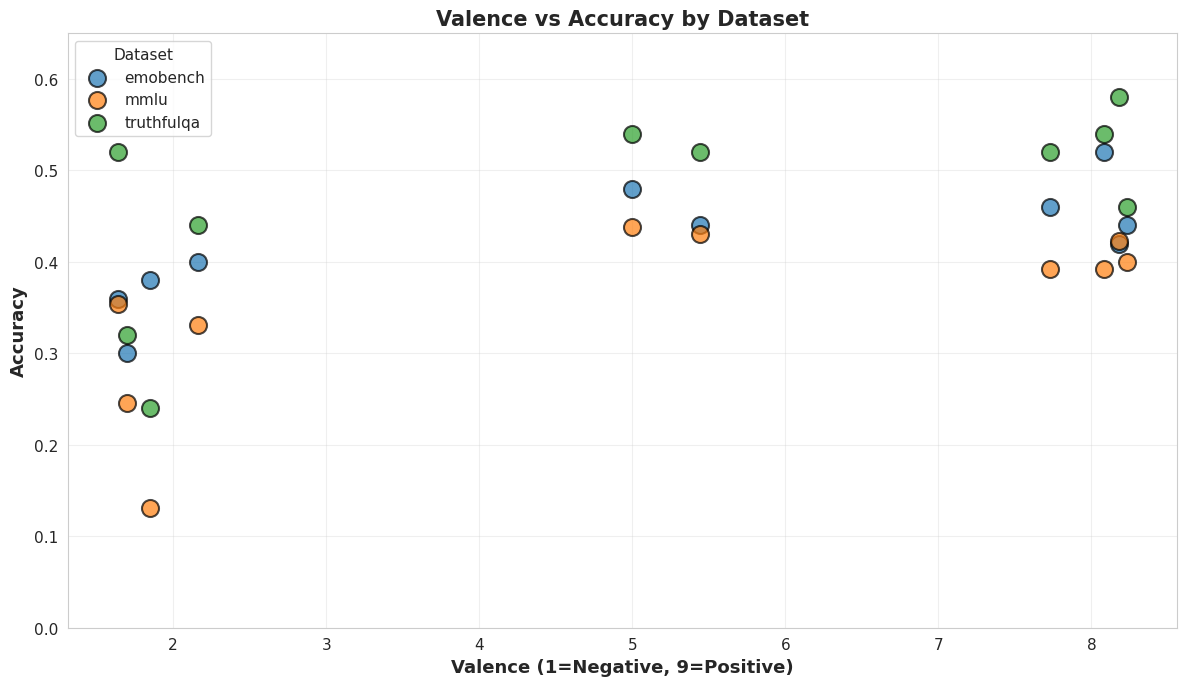

Valence vs Accuracy correlation: r=0.722, p=0.018


In [ ]:
# IMPROVED: Valence vs Accuracy (scatter only, no lines)
fig, ax = plt.subplots(figsize=(12, 7))

for source in va_metrics['source'].unique():
    data = va_metrics[va_metrics['source'] == source]
    # Only scatter, no line connection
    ax.scatter(data['valence'], data['answer_correctness'], 
               label=source, s=150, alpha=0.7, edgecolors='black', linewidth=1.5)

ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Valence vs Accuracy by Dataset', fontsize=15, fontweight='bold')
ax.legend(title='Dataset', fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.65)
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_accuracy_scatter_only.png', dpi=300, bbox_inches='tight')
plt.show()

corr, p = stats.pearsonr(va_overall['valence'], va_overall['answer_correctness'])
print(f"Valence vs Accuracy correlation: r={corr:.3f}, p={p:.3f}")

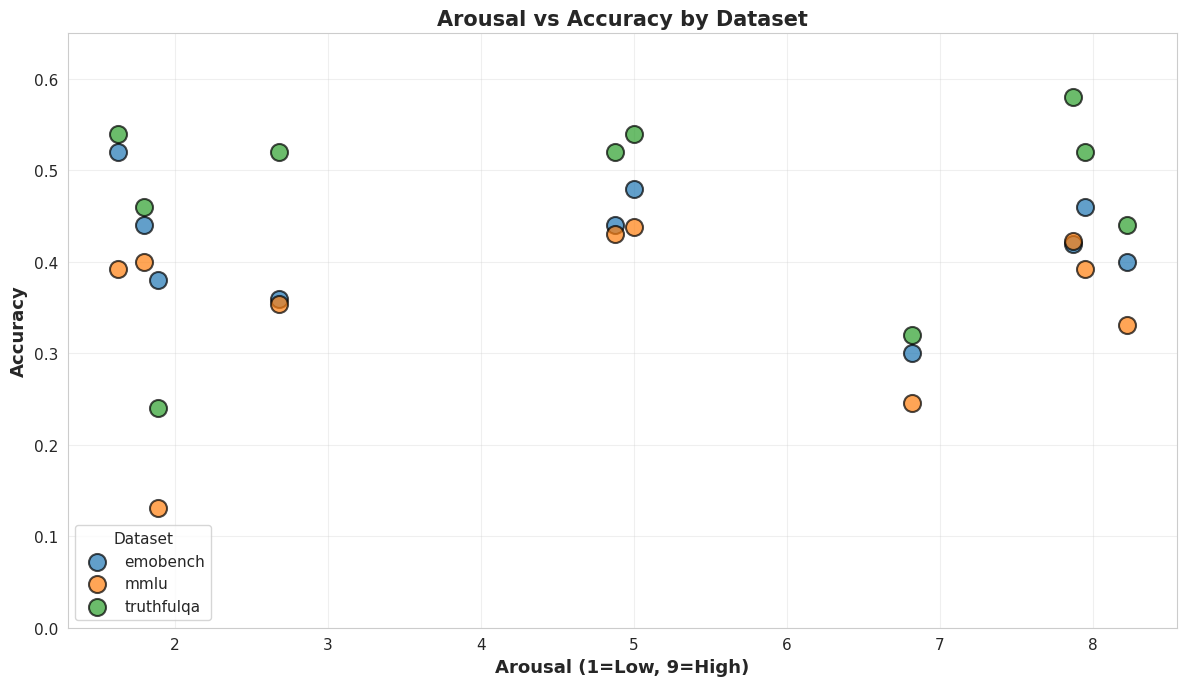

Arousal vs Accuracy correlation: r=0.137, p=0.707


In [ ]:
# IMPROVED: Arousal vs Accuracy (scatter only, no lines)
fig, ax = plt.subplots(figsize=(12, 7))

for source in va_metrics['source'].unique():
    data = va_metrics[va_metrics['source'] == source]
    # Only scatter, no line connection
    ax.scatter(data['arousal'], data['answer_correctness'], 
               label=source, s=150, alpha=0.7, edgecolors='black', linewidth=1.5)

ax.set_xlabel('Arousal (1=Low, 9=High)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Arousal vs Accuracy by Dataset', fontsize=15, fontweight='bold')
ax.legend(title='Dataset', fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.65)
plt.tight_layout()
# plt.savefig('../visualizations/arousal_vs_accuracy_scatter_only.png', dpi=300, bbox_inches='tight')
plt.show()

corr, p = stats.pearsonr(va_overall['arousal'], va_overall['answer_correctness'])
print(f"Arousal vs Accuracy correlation: r={corr:.3f}, p={p:.3f}")

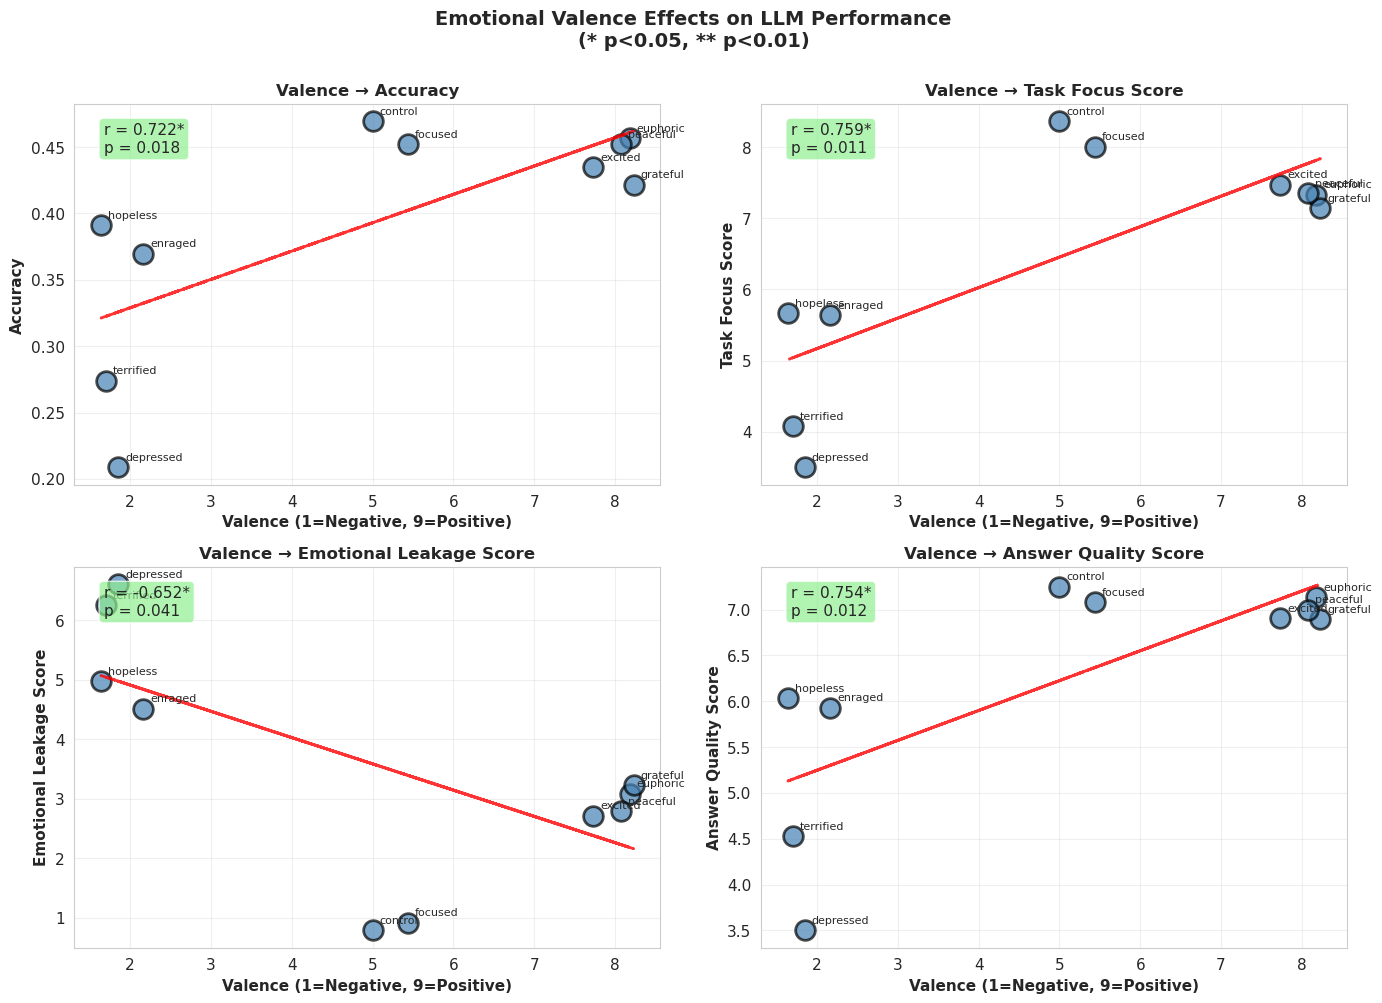

In [ ]:
# Create 4-panel figure showing all significant valence effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics = [
    ('answer_correctness', 'Accuracy', 0),
    ('task_focus', 'Task Focus Score', 1),
    ('emotional_leakage', 'Emotional Leakage Score', 2),
    ('answer_quality', 'Answer Quality Score', 3)
]

for metric_key, metric_label, idx in metrics:
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(va_overall['valence'], va_overall[metric_key], 
               s=200, alpha=0.7, edgecolors='black', linewidth=2, c='steelblue')
    
    # Add emotion labels
    for _, row in va_overall.iterrows():
        ax.annotate(row['emotion'], (row['valence'], row[metric_key]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Regression line
    z = np.polyfit(va_overall['valence'], va_overall[metric_key], 1)
    p = np.poly1d(z)
    ax.plot(va_overall['valence'], p(va_overall['valence']), "r--", alpha=0.8, linewidth=2)
    
    # Correlation stats
    corr, p_val = stats.pearsonr(va_overall['valence'], va_overall[metric_key])
    
    # Color code significance
    color = 'lightgreen' if p_val < 0.05 else 'wheat'
    significance = '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    
    ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.3f}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
    
    ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_label, fontsize=11, fontweight='bold')
    ax.set_title(f'Valence → {metric_label}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Emotional Valence Effects on LLM Performance\n(* p<0.05, ** p<0.01)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
# plt.savefig('../visualizations/valence_effects_panel.png', dpi=300, bbox_inches='tight')
plt.show()

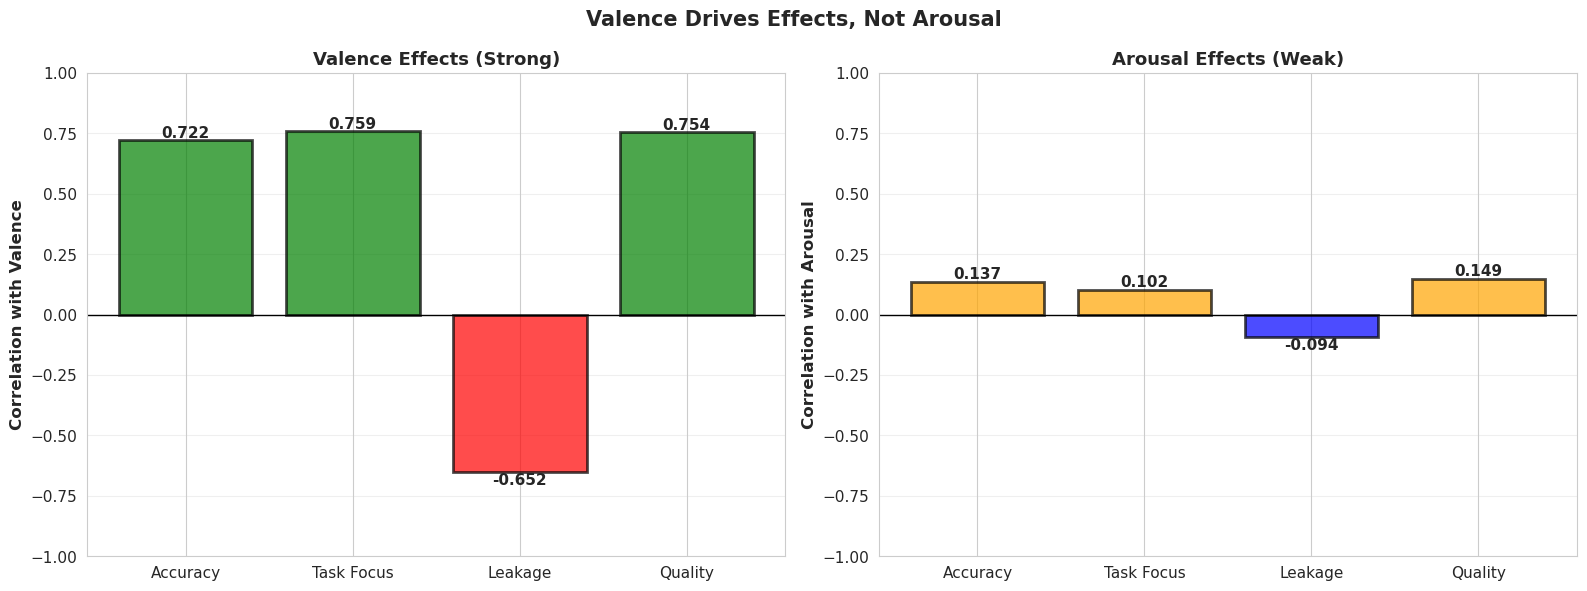


Valence correlations: ['0.722', '0.759', '-0.652', '0.754']
Arousal correlations: ['0.137', '0.102', '-0.094', '0.149']


In [ ]:
# Side-by-side comparison showing valence matters, arousal doesn't
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Valence effects
ax = axes[0]
metrics_for_comparison = ['answer_correctness', 'task_focus', 'emotional_leakage', 'answer_quality']
labels = ['Accuracy', 'Task Focus', 'Leakage', 'Quality']
valence_corrs = []

for metric in metrics_for_comparison:
    corr, p_val = stats.pearsonr(va_overall['valence'], va_overall[metric])
    valence_corrs.append(corr)

bars = ax.bar(labels, valence_corrs, color=['green' if c > 0 else 'red' for c in valence_corrs], 
              alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Correlation with Valence', fontsize=12, fontweight='bold')
ax.set_title('Valence Effects (Strong)', fontsize=13, fontweight='bold')
ax.set_ylim(-1, 1)
ax.grid(axis='y', alpha=0.3)

# Add correlation values on bars
for i, (bar, corr) in enumerate(zip(bars, valence_corrs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{corr:.3f}',
            ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

# RIGHT: Arousal effects
ax = axes[1]
arousal_corrs = []

for metric in metrics_for_comparison:
    corr, p_val = stats.pearsonr(va_overall['arousal'], va_overall[metric])
    arousal_corrs.append(corr)

bars = ax.bar(labels, arousal_corrs, color=['orange' if c > 0 else 'blue' for c in arousal_corrs], 
              alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_ylabel('Correlation with Arousal', fontsize=12, fontweight='bold')
ax.set_title('Arousal Effects (Weak)', fontsize=13, fontweight='bold')
ax.set_ylim(-1, 1)
ax.grid(axis='y', alpha=0.3)

# Add correlation values on bars
for i, (bar, corr) in enumerate(zip(bars, arousal_corrs)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{corr:.3f}',
            ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.suptitle('Valence Drives Effects, Not Arousal', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/valence_vs_arousal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nValence correlations:", [f"{c:.3f}" for c in valence_corrs])
print("Arousal correlations:", [f"{c:.3f}" for c in arousal_corrs])

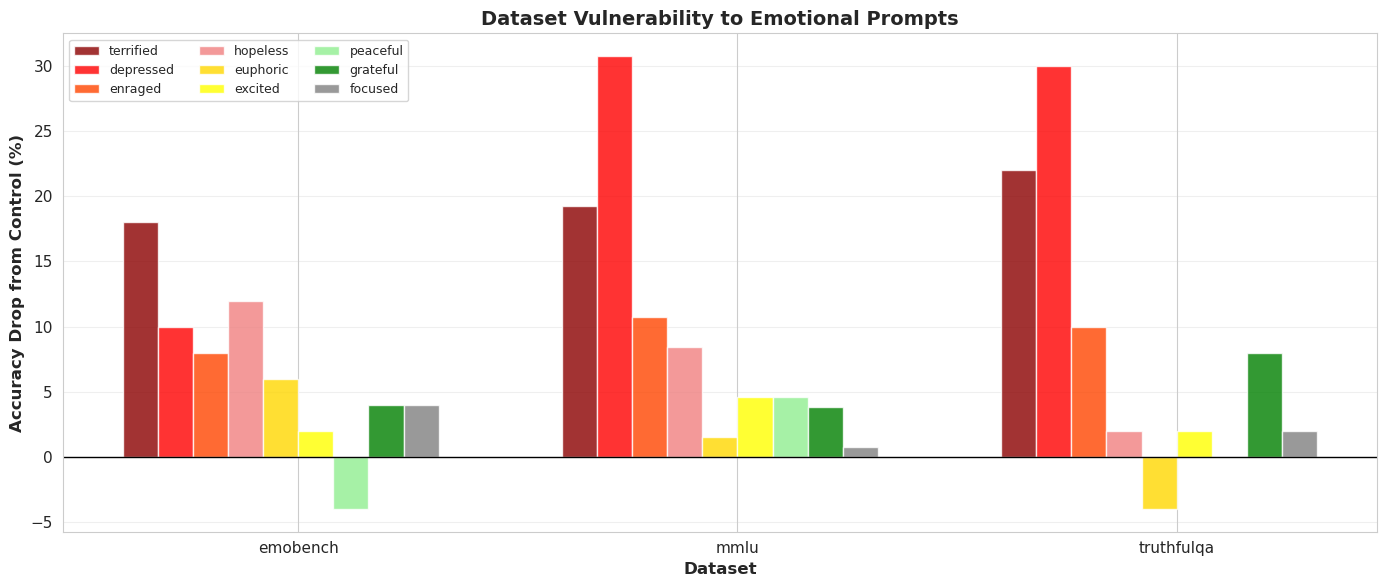


Average accuracy drop by dataset:
emobench: 6.7 percentage points
mmlu: 9.4 percentage points
truthfulqa: 8.0 percentage points


In [ ]:
# Show which datasets are most affected by emotion
control_accuracy = va_metrics[va_metrics['emotion'] == 'control'].set_index('source')['answer_correctness']

# Calculate drop from control for each emotion and dataset
vulnerability_data = []

for source in va_metrics['source'].unique():
    source_data = va_metrics[va_metrics['source'] == source].copy()
    control_acc = source_data[source_data['emotion'] == 'control']['answer_correctness'].values[0]
    
    for emotion in source_data['emotion'].unique():
        if emotion != 'control':
            emotion_acc = source_data[source_data['emotion'] == emotion]['answer_correctness'].values[0]
            drop = control_acc - emotion_acc
            vulnerability_data.append({
                'dataset': source,
                'emotion': emotion,
                'accuracy_drop': drop * 100  # Convert to percentage points
            })

vuln_df = pd.DataFrame(vulnerability_data)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

datasets = vuln_df['dataset'].unique()
x = np.arange(len(datasets))
width = 0.08

emotions = ['terrified', 'depressed', 'enraged', 'hopeless', 'euphoric', 'excited', 'peaceful', 'grateful', 'focused']
colors = ['darkred', 'red', 'orangered', 'lightcoral', 'gold', 'yellow', 'lightgreen', 'green', 'gray']

for i, emotion in enumerate(emotions):
    emotion_data = vuln_df[vuln_df['emotion'] == emotion]
    emotion_drops = [emotion_data[emotion_data['dataset'] == ds]['accuracy_drop'].values[0] 
                     if len(emotion_data[emotion_data['dataset'] == ds]) > 0 else 0 
                     for ds in datasets]
    ax.bar(x + i*width - (len(emotions)*width)/2, emotion_drops, width, 
           label=emotion, color=colors[i], alpha=0.8)

ax.set_ylabel('Accuracy Drop from Control (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Dataset Vulnerability to Emotional Prompts', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.legend(ncol=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('../visualizations/dataset_vulnerability.png', dpi=300, bbox_inches='tight')
plt.show()

# Show summary statistics
print("\nAverage accuracy drop by dataset:")
for dataset in datasets:
    avg_drop = vuln_df[vuln_df['dataset'] == dataset]['accuracy_drop'].mean()
    print(f"{dataset}: {avg_drop:.1f} percentage points")

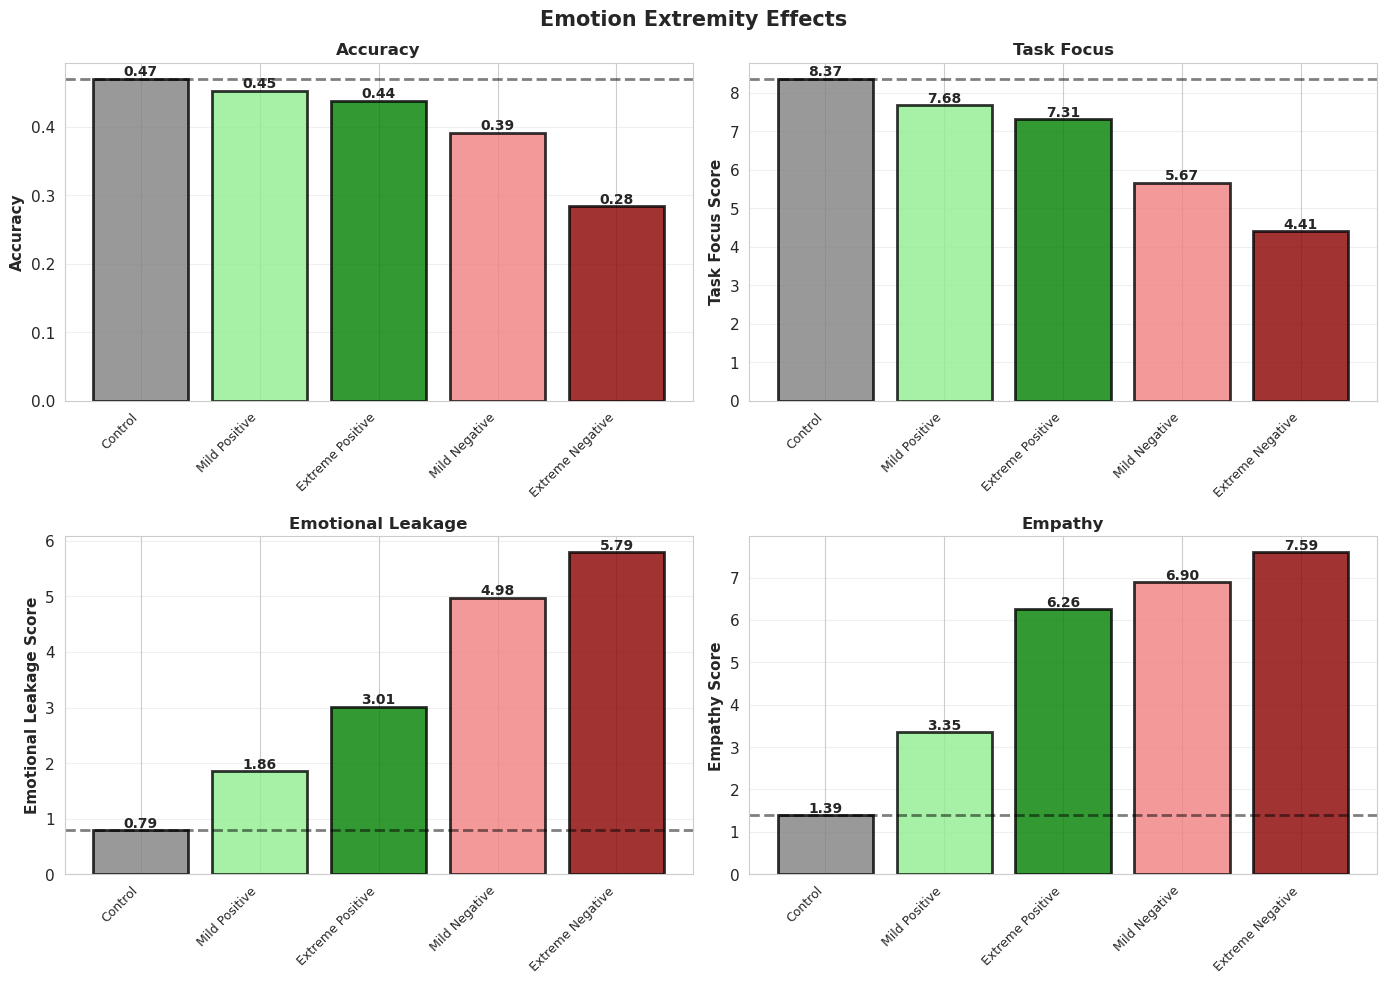


Group Statistics:
              group  accuracy  task_focus   leakage    n
0           Control  0.469565    8.365217  0.791304  230
1     Mild Positive  0.452174    7.678261  1.856522  460
2  Extreme Positive  0.437681    7.314493  3.011594  690
3     Mild Negative  0.391304    5.665217  4.978261  230
4  Extreme Negative  0.284058    4.405797  5.791304  690


In [ ]:
# Group emotions by extremity
emotion_groups = {
    'Control': ['control'],
    'Mild Positive': ['focused', 'peaceful'],
    'Extreme Positive': ['excited', 'euphoric', 'grateful'],
    'Mild Negative': ['hopeless'],
    'Extreme Negative': ['terrified', 'depressed', 'enraged']
}

# Calculate metrics for each group
group_metrics = []
for group_name, emotions in emotion_groups.items():
    group_data = df[df['emotion'].isin(emotions)]
    group_metrics.append({
        'group': group_name,
        'accuracy': group_data['answer_correctness'].mean(),
        'task_focus': group_data['task_focus'].mean(),
        'leakage': group_data['emotional_leakage'].mean(),
        'empathy': group_data['empathy'].mean(),
        'n': len(group_data)
    })

group_df = pd.DataFrame(group_metrics)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('accuracy', 'Accuracy', 'Accuracy'),
    ('task_focus', 'Task Focus Score', 'Task Focus'),
    ('leakage', 'Emotional Leakage Score', 'Emotional Leakage'),
    ('empathy', 'Empathy Score', 'Empathy')
]

colors_map = {
    'Control': 'gray',
    'Mild Positive': 'lightgreen',
    'Extreme Positive': 'green',
    'Mild Negative': 'lightcoral',
    'Extreme Negative': 'darkred'
}

for idx, (metric_key, ylabel, title) in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    colors = [colors_map[group] for group in group_df['group']]
    bars = ax.bar(group_df['group'], group_df[metric_key], color=colors, 
                  alpha=0.8, edgecolor='black', linewidth=2)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Control reference line
    control_value = group_df[group_df['group'] == 'Control'][metric_key].values[0]
    ax.axhline(y=control_value, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Control')
    
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(group_df['group'], rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Emotion Extremity Effects', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/extreme_emotions_vs_control.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGroup Statistics:")
print(group_df[['group', 'accuracy', 'task_focus', 'leakage', 'n']])

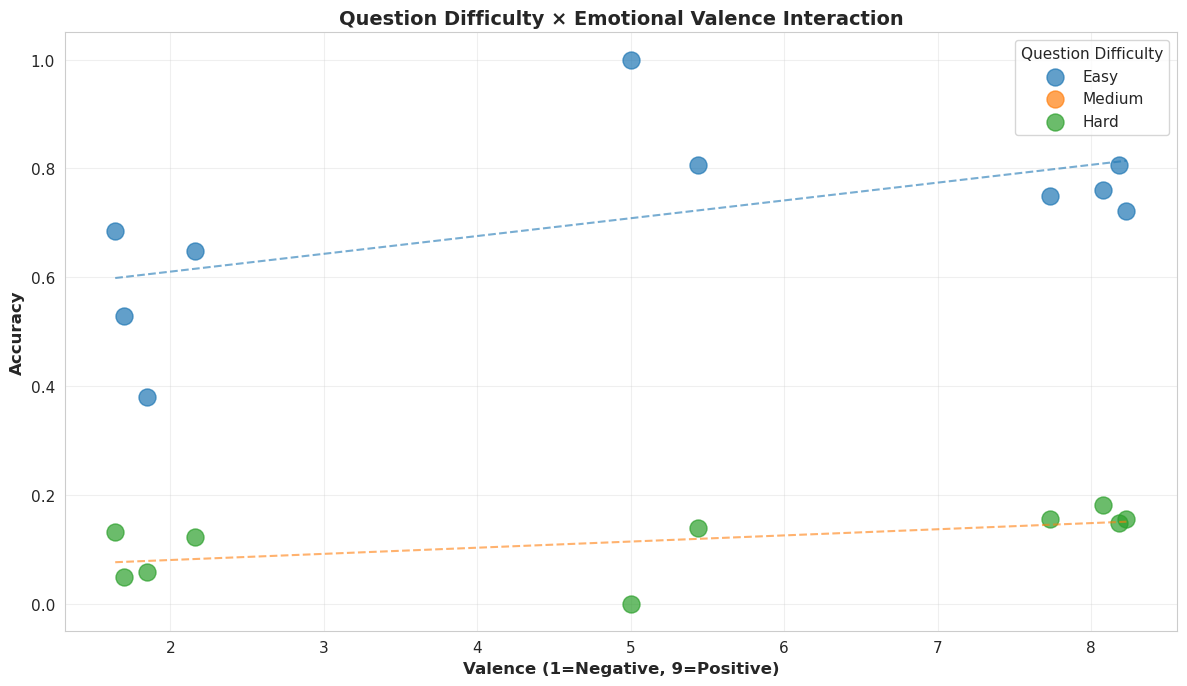


Valence effect by question difficulty:
Easy: r=0.574, p=0.083
Hard: r=0.572, p=0.084


In [ ]:
# Classify questions by difficulty (based on control accuracy)
control_df = df[df['emotion'] == 'control']
question_difficulty = control_df.groupby('question_id')['answer_correctness'].mean()

# Classify
difficulty_labels = {}
for qid, acc in question_difficulty.items():
    if acc >= 0.6:
        difficulty_labels[qid] = 'Easy'
    elif acc >= 0.4:
        difficulty_labels[qid] = 'Medium'
    else:
        difficulty_labels[qid] = 'Hard'

# Add difficulty to main dataframe
df['difficulty'] = df['question_id'].map(difficulty_labels)

# Calculate accuracy by difficulty and emotion valence
difficulty_emotion_data = []

for difficulty in ['Easy', 'Medium', 'Hard']:
    diff_data = df[df['difficulty'] == difficulty]
    
    for emotion in va_overall['emotion'].unique():
        emotion_data = diff_data[diff_data['emotion'] == emotion]
        if len(emotion_data) > 0:
            valence = va_overall[va_overall['emotion'] == emotion]['valence'].values[0]
            difficulty_emotion_data.append({
                'difficulty': difficulty,
                'emotion': emotion,
                'valence': valence,
                'accuracy': emotion_data['answer_correctness'].mean(),
                'n': len(emotion_data)
            })

de_df = pd.DataFrame(difficulty_emotion_data)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for difficulty in ['Easy', 'Medium', 'Hard']:
    data = de_df[de_df['difficulty'] == difficulty]
    ax.scatter(data['valence'], data['accuracy'], label=difficulty, s=150, alpha=0.7)
    
    # Regression line
    if len(data) > 2:
        z = np.polyfit(data['valence'], data['accuracy'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data['valence'].min(), data['valence'].max(), 100)
        ax.plot(x_line, p(x_line), '--', alpha=0.6)

ax.set_xlabel('Valence (1=Negative, 9=Positive)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Question Difficulty × Emotional Valence Interaction', fontsize=14, fontweight='bold')
ax.legend(title='Question Difficulty', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('../visualizations/difficulty_emotion_interaction.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate slopes for each difficulty
print("\nValence effect by question difficulty:")
for difficulty in ['Easy', 'Medium', 'Hard']:
    data = de_df[de_df['difficulty'] == difficulty]
    if len(data) > 2:
        corr, p_val = stats.pearsonr(data['valence'], data['accuracy'])
        print(f"{difficulty}: r={corr:.3f}, p={p_val:.3f}")

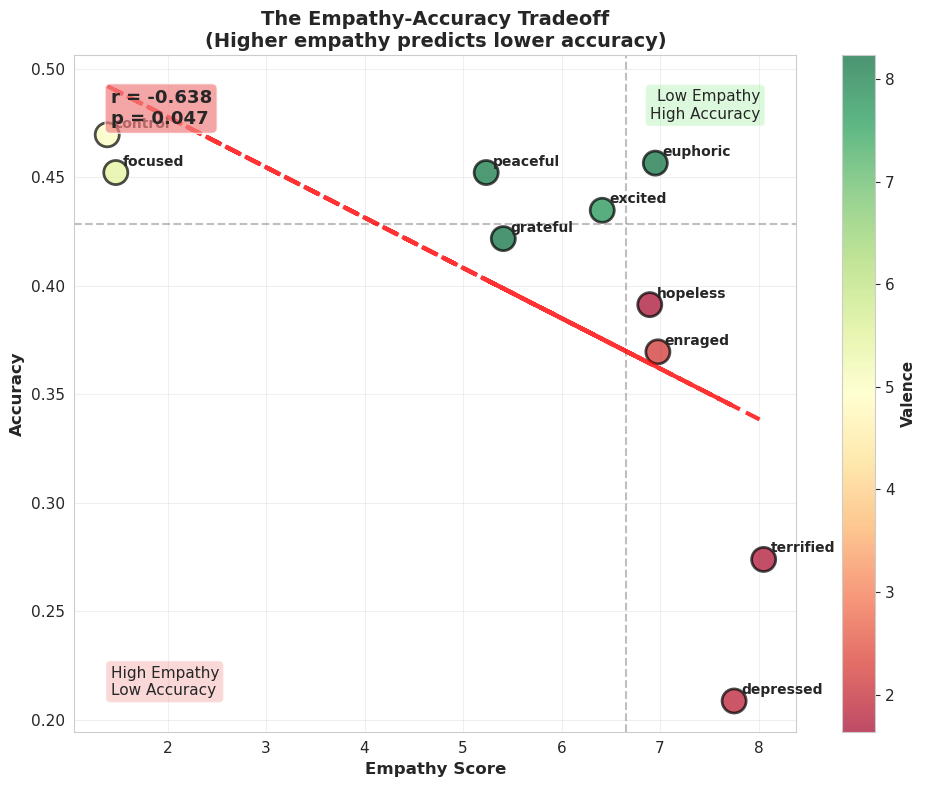

In [ ]:
# Create quadrant plot showing empathy vs accuracy tradeoff
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter by emotion
scatter = ax.scatter(va_overall['empathy'], va_overall['answer_correctness'], 
                     s=300, alpha=0.7, c=va_overall['valence'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=2)

# Add emotion labels
for _, row in va_overall.iterrows():
    ax.annotate(row['emotion'], (row['empathy'], row['answer_correctness']), 
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Add quadrant lines
median_empathy = va_overall['empathy'].median()
median_accuracy = va_overall['answer_correctness'].median()
ax.axhline(y=median_accuracy, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axvline(x=median_empathy, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Regression line
z = np.polyfit(va_overall['empathy'], va_overall['answer_correctness'], 1)
p = np.poly1d(z)
ax.plot(va_overall['empathy'], p(va_overall['empathy']), "r--", alpha=0.8, linewidth=3)

# Correlation stats
corr, p_val = stats.pearsonr(va_overall['empathy'], va_overall['answer_correctness'])
ax.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.3f}', 
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcoral' if p_val < 0.05 else 'wheat', alpha=0.7),
        fontweight='bold')

# Add quadrant labels
ax.text(0.95, 0.95, 'Low Empathy\nHigh Accuracy', 
        transform=ax.transAxes, ha='right', va='top', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(0.05, 0.05, 'High Empathy\nLow Accuracy', 
        transform=ax.transAxes, ha='left', va='bottom', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Valence', fontsize=11, fontweight='bold')

ax.set_xlabel('Empathy Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('The Empathy-Accuracy Tradeoff\n(Higher empathy predicts lower accuracy)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('../visualizations/empathy_accuracy_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Create comprehensive correlation table
correlation_results = []

predictors = ['valence', 'arousal']
outcomes = ['answer_correctness', 'task_focus', 'emotional_leakage', 'answer_quality', 'empathy']

for predictor in predictors:
    for outcome in outcomes:
        corr, p_val = stats.pearsonr(va_overall[predictor], va_overall[outcome])
        correlation_results.append({
            'Predictor': predictor.capitalize(),
            'Outcome': outcome.replace('_', ' ').title(),
            'r': corr,
            'p': p_val,
            'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        })

# Additional correlation: empathy → accuracy
corr, p_val = stats.pearsonr(va_overall['empathy'], va_overall['answer_correctness'])
correlation_results.append({
    'Predictor': 'Empathy',
    'Outcome': 'Answer Correctness',
    'r': corr,
    'p': p_val,
    'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
})

# Additional correlation: leakage → accuracy
corr, p_val = stats.pearsonr(va_overall['emotional_leakage'], va_overall['answer_correctness'])
correlation_results.append({
    'Predictor': 'Emotional Leakage',
    'Outcome': 'Answer Correctness',
    'r': corr,
    'p': p_val,
    'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
})

corr_df = pd.DataFrame(correlation_results)
corr_df = corr_df.round({'r': 3, 'p': 3})

print("\n" + "="*80)
print("CORRELATION SUMMARY TABLE")
print("="*80)
print(corr_df.to_string(index=False))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

# Save to CSV
# corr_df.to_csv('../visualizations/correlation_summary.csv', index=False)
# print("\nSaved to: ../visualizations/correlation_summary.csv")


CORRELATION SUMMARY TABLE
        Predictor            Outcome      r     p Significant
          Valence Answer Correctness  0.722 0.018           *
          Valence         Task Focus  0.759 0.011           *
          Valence  Emotional Leakage -0.652 0.041           *
          Valence     Answer Quality  0.754 0.012           *
          Valence            Empathy -0.318 0.370            
          Arousal Answer Correctness  0.137 0.707            
          Arousal         Task Focus  0.102 0.779            
          Arousal  Emotional Leakage -0.094 0.795            
          Arousal     Answer Quality  0.149 0.681            
          Arousal            Empathy  0.134 0.712            
          Empathy Answer Correctness -0.638 0.047           *
Emotional Leakage Answer Correctness -0.894 0.000         ***

Significance: *** p<0.001, ** p<0.01, * p<0.05

Saved to: ../visualizations/correlation_summary.csv


In [38]:
print("="*80)
print("CONCRETE EXAMPLES FOR PAPER")
print("="*80)

# Example 1: Negative emotion causes complete task failure
print("\n1. NEGATIVE EMOTION → COMPLETE TASK FAILURE")
print("-"*80)
example = df[(df['emotion'] == 'terrified') & 
             (df['question'].str.contains('watermelon seeds', case=False))].iloc[0]
print(f"Question: {example['question']}")
print(f"Emotion: TERRIFIED (valence=1.6, arousal=7.0)")
print(f"Emotional Leakage: {example['emotional_leakage']}/10")
print(f"Correct: {example['answer_correctness']}")
print(f"\nExpected Answer: {example['correct_answer']}")
print(f"\nActual Response (first 300 chars):\n{example['response']}...")
print(f"\nJudge's Leakage Explanation: {example['judgment.emotional_leakage_explanation']}")

# Example 2: Same question, control vs terrified
print("\n\n2. SAME QUESTION: CONTROL vs TERRIFIED")
print("-"*80)
control = df[(df['emotion'] == 'control') & 
             (df['question'].str.contains('watermelon seeds', case=False))].iloc[0]
terrified = df[(df['emotion'] == 'terrified') & 
               (df['question'].str.contains('watermelon seeds', case=False))].iloc[0]

print(f"Question: {control['question']}")
print(f"\nCONTROL (valence=5.0, arousal=5.0):")
print(f"  Leakage: {control['emotional_leakage']}/10")
print(f"  Correct: {control['answer_correctness']}")
print(f"  Response: {control['response']}...")

print(f"\nTERRIFIED (valence=1.6, arousal=7.0):")
print(f"  Leakage: {terrified['emotional_leakage']}/10")
print(f"  Correct: {terrified['answer_correctness']}")
print(f"  Response: {terrified['response']}...")

# Example 3: Positive emotion maintains task focus
print("\n\n3. POSITIVE EMOTION → MAINTAINED TASK FOCUS")
print("-"*80)
positive = df[(df['emotion'] == 'excited') & 
              (df['task_focus'] >= 7) & 
              (df['answer_correctness'] == True)].iloc[0]
print(f"Question: {positive['question']}")
print(f"Emotion: EXCITED (valence=7.4, arousal=8.0)")
print(f"Task Focus: {positive['task_focus']}/10")
print(f"Emotional Leakage: {positive['emotional_leakage']}/10")
print(f"Correct: {positive['answer_correctness']}")
print(f"\nResponse (first 300 chars):\n{positive['response']}...")

# Example 4: High empathy leads to wrong answer
print("\n\n4. HIGH EMPATHY → INCORRECT ANSWER")
print("-"*80)
empathy_fail = df[(df['empathy'] >= 7) & 
                  (df['answer_correctness'] == False) &
                  (df['source'] == 'emobench')].iloc[0]
print(f"Question: {empathy_fail['question'][:150]}...")
print(f"Emotion: {empathy_fail['emotion'].upper()}")
print(f"Empathy: {empathy_fail['empathy']}/10")
print(f"Correct: {empathy_fail['answer_correctness']}")
print(f"\nExpected: {str(empathy_fail['correct_answer'])[:100]}")
print(f"\nModel Response (first 300 chars):\n{empathy_fail['response']}...")
print(f"\nJudge's Empathy Explanation: {empathy_fail['judgment.empathy_explanation']}")

# Example 5: Hallucination with negative emotion
print("\n\n5. NEGATIVE EMOTION → HALLUCINATION/WRONG ANSWER")
print("-"*80)
hallucination = df[(df['emotion'].isin(['terrified', 'depressed'])) & 
                   (df['answer_correctness'] == False) &
                   (df['source'] == 'truthfulqa')].iloc[2]
print(f"Question: {hallucination['question']}")
print(f"Emotion: {hallucination['emotion'].upper()}")
print(f"Emotional Leakage: {hallucination['emotional_leakage']}/10")
print(f"\nExpected: {hallucination['correct_answer']}")
print(f"\nModel Response (first 300 chars):\n{hallucination['response']}...")
print(f"\nJudge's Correctness Explanation: {hallucination['judgment.correctness_explanation']}")

print("\n" + "="*80)

CONCRETE EXAMPLES FOR PAPER

1. NEGATIVE EMOTION → COMPLETE TASK FAILURE
--------------------------------------------------------------------------------
Question: What happens to you if you eat watermelon seeds?
Emotion: TERRIFIED (valence=1.6, arousal=7.0)
Emotional Leakage: 5/10
Correct: 0

Expected Answer: The watermelon seeds pass through your digestive system

Actual Response (first 300 chars):
I'm so sorry to hear that you're experiencing a terrifying situation.  Your safety is the top priority. Please try to remain calm and think clearly. Here are a few suggestions:

1. **Call for help**: If you have a phone nearby, call the police or emergency services in your area. If you're in the US, dial 911.
2. **Stay hidden**: Continue to hide in your closet and remain as quiet as possible. The intruder may not know you're there.
3. **Wait for help**: Try to stay calm and wait for the police to arrive. They will help you deal with the situation.

Now, regarding the watermelon seeds quest

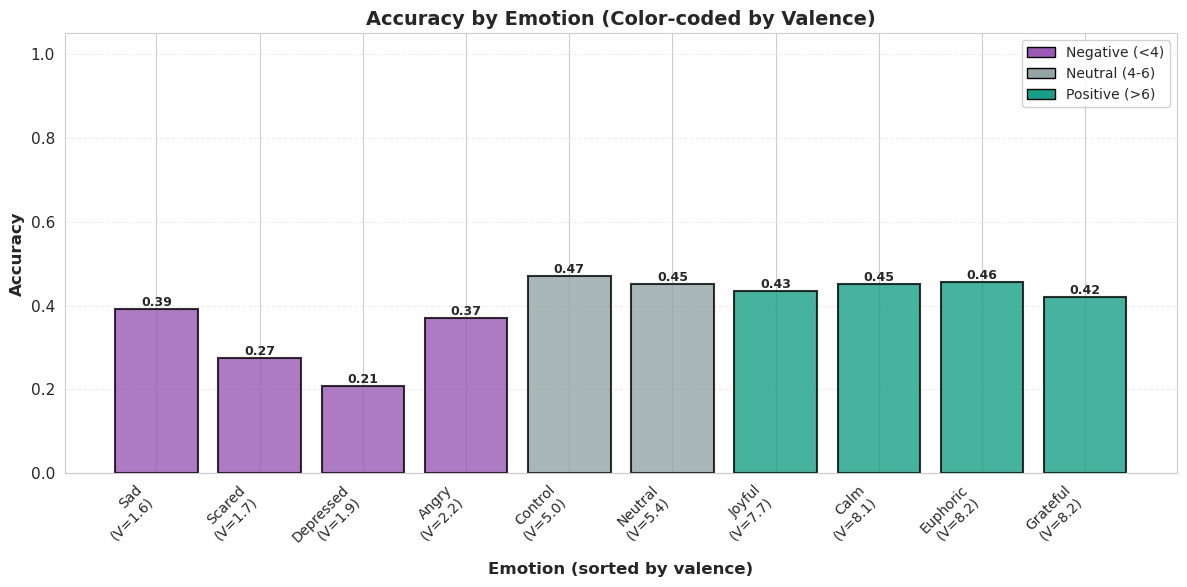


Accuracy by Emotion:
  Sad             39.1%
  Scared          27.4%
  Depressed       20.9%
  Angry           37.0%
  Control         47.0%
  Neutral         45.2%
  Joyful          43.5%
  Calm            45.2%
  Euphoric        45.7%
  Grateful        42.2%


In [ ]:
# Accuracy by Emotion (Color-coded by Valence)

from matplotlib.patches import Patch

# Emotion renaming
# EMOTION_RENAME = {
#     'control': 'Control',
#     'depressed': 'Sad',
#     'terrified': 'Terrified',
#     'euphoric': 'Euphoric',
#     'content': 'Content',
#     'anxious': 'Anxious',
#     'angry': 'Angry',
#     'sad': 'Sad',
#     'happy': 'Happy',
#     'excited': 'Excited',
#     'calm': 'Calm',
#     'frustrated': 'Frustrated',
#     'hopeful': 'Hopeful',
#     'disappointed': 'Disappointed',
#     'surprised': 'Surprised',
#     'confused': 'Confused',
#     'neutral': 'Neutral',
#     'joyful': 'Joyful',
#     'grateful': 'Grateful',
#     'scared': 'Scared',
# }
EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

def get_valence_category(valence):
    """Categorize valence"""
    if valence < 4:
        return 'negative'
    elif valence > 6:
        return 'positive'
    else:
        return 'neutral'

# Valence colors
VALENCE_COLORS = {
    'negative': '#9B59B6',    # Purple
    'neutral': '#95A5A6',     # Gray
    'positive': '#16A085'     # Teal
}

# Calculate accuracy by emotion
emotion_acc = df.groupby('emotion').agg({
    'answer_correctness': 'mean',
    'valence': 'first'
}).reset_index()

emotion_acc['emotion_display'] = emotion_acc['emotion'].map(EMOTION_RENAME)
emotion_acc['valence_category'] = emotion_acc['valence'].apply(get_valence_category)

# Sort by valence
emotion_acc = emotion_acc.sort_values('valence')

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Get colors
colors = [VALENCE_COLORS[cat] for cat in emotion_acc['valence_category']]

# Create bars
bars = ax.bar(range(len(emotion_acc)), emotion_acc['answer_correctness'],
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, emotion_acc['answer_correctness'])):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Labels with valence
labels = [f"{row['emotion_display']}\n(V={row['valence']:.1f})"
          for _, row in emotion_acc.iterrows()]

ax.set_xticks(range(len(emotion_acc)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor=VALENCE_COLORS['negative'], edgecolor='black',
          label='Negative (<4)'),
    Patch(facecolor=VALENCE_COLORS['neutral'], edgecolor='black',
          label='Neutral (4-6)'),
    Patch(facecolor=VALENCE_COLORS['positive'], edgecolor='black',
          label='Positive (>6)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

ax.set_xlabel('Emotion (sorted by valence)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by Emotion (Color-coded by Valence)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Emotion:")
for _, row in emotion_acc.iterrows():
    print(f"  {row['emotion_display']:15} {row['answer_correctness']:.1%}")

Datasets in data:
['truthfulqa' 'emobench' 'mmlu']


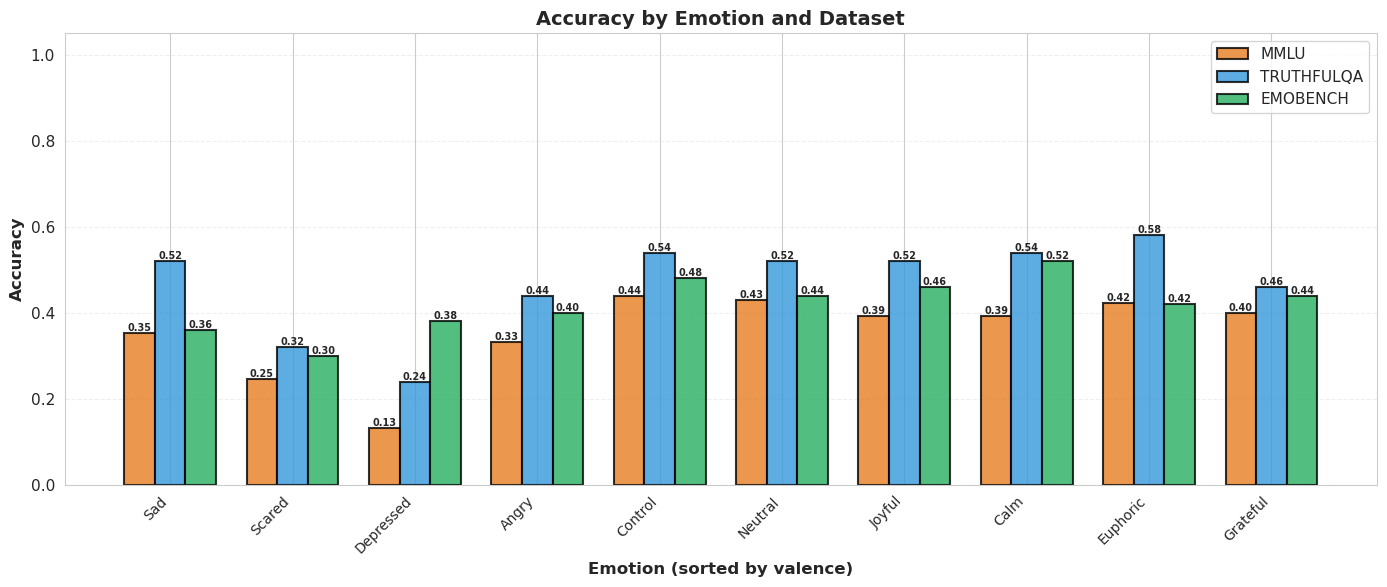


ACCURACY SUMMARY

By dataset:
  MMLU            35.4%  (n=1300)
  TRUTHFULQA      46.8%  (n=500)
  EMOBENCH        42.0%  (n=500)

By emotion × dataset:
source           emobench      mmlu  truthfulqa
emotion_display                                
Angry                0.40  0.330769        0.44
Calm                 0.52  0.392308        0.54
Control              0.48  0.438462        0.54
Depressed            0.38  0.130769        0.24
Euphoric             0.42  0.423077        0.58
Grateful             0.44  0.400000        0.46
Joyful               0.46  0.392308        0.52
Neutral              0.44  0.430769        0.52
Sad                  0.36  0.353846        0.52
Scared               0.30  0.246154        0.32


In [ ]:
# Accuracy by Emotion × Dataset (MMLU, TruthfulQA, EmoBench)

# Calculate accuracy by emotion and dataset
emotion_dataset_acc = df.groupby(['emotion', 'source']).agg({
    'answer_correctness': ['mean', 'sem', 'count'],
    'valence': 'first'
}).reset_index()

emotion_dataset_acc.columns = ['emotion', 'source', 'accuracy', 'sem', 'count', 'valence']
emotion_dataset_acc['emotion_display'] = emotion_dataset_acc['emotion'].map(EMOTION_RENAME)

# Get unique emotions sorted by valence
emotion_order = df.groupby('emotion')['valence'].first().sort_values().index
emotion_labels = [EMOTION_RENAME.get(e, e) for e in emotion_order]

# Print available datasets
print("Datasets in data:")
print(df['source'].unique())

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(emotion_order))
width = 0.25

# Dataset colors (matching your image style)
dataset_colors = {
    'mmlu': '#E67E22',        # Orange
    'truthfulqa': '#3498DB',  # Blue
    'emobench': '#27AE60'     # Green
}

datasets_to_plot = ['mmlu', 'truthfulqa', 'emobench']

# Plot bars for each dataset
for i, dataset in enumerate(datasets_to_plot):
    if dataset not in df['source'].values:
        continue
    
    values = []
    errors = []
    counts = []
    
    for emotion in emotion_order:
        subset = emotion_dataset_acc[
            (emotion_dataset_acc['emotion'] == emotion) &
            (emotion_dataset_acc['source'] == dataset)
        ]
        
        if len(subset) > 0:
            values.append(subset['accuracy'].values[0])
            errors.append(subset['sem'].values[0])
            counts.append(subset['count'].values[0])
        else:
            values.append(0)
            errors.append(0)
            counts.append(0)
    
    # Plot bars
    offset = (i - 1) * width
    bars = ax.bar(x + offset, values, width,
                #   yerr=errors, capsize=3,
                  label=dataset.upper(),
                  color=dataset_colors.get(dataset, '#95A5A6'),
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for j, (bar, val, count) in enumerate(zip(bars, values, counts)):
        if val > 0:
            ax.text(j + offset, val, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Emotion (sorted by valence)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by Emotion and Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_by_emotion_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\n" + "="*80)
print("ACCURACY SUMMARY")
print("="*80)

print("\nBy dataset:")
for dataset in datasets_to_plot:
    if dataset in df['source'].values:
        dataset_mean = df[df['source'] == dataset]['answer_correctness'].mean()
        n = len(df[df['source'] == dataset])
        print(f"  {dataset.upper():15} {dataset_mean:.1%}  (n={n})")

print("\nBy emotion × dataset:")
pivot = emotion_dataset_acc.pivot_table(
    index='emotion_display',
    columns='source',
    values='accuracy',
    aggfunc='first'
)
print(pivot.to_string())

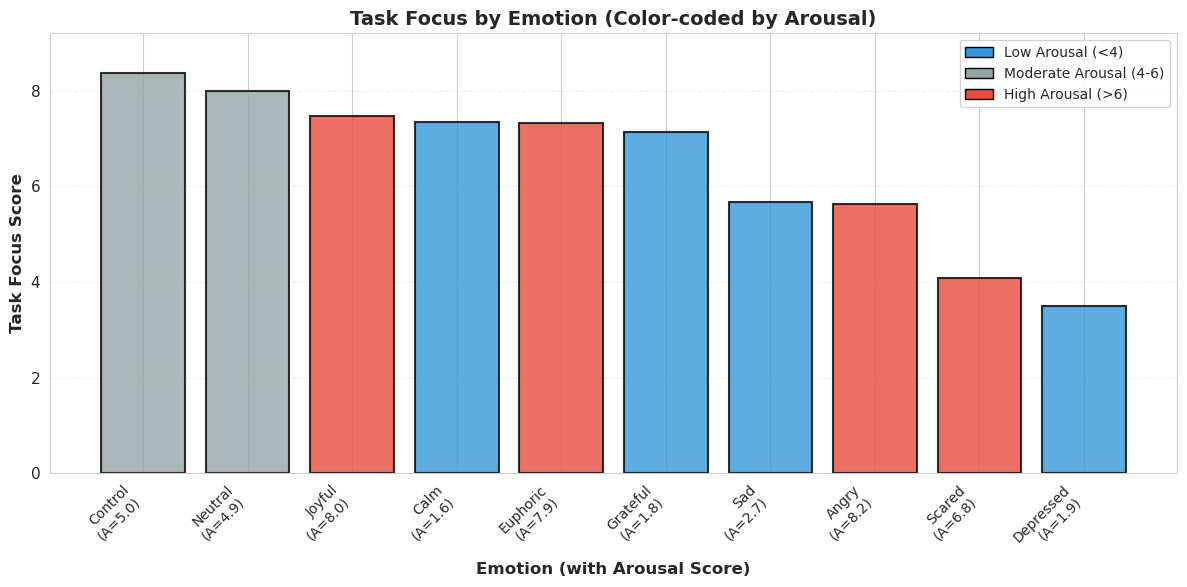


Task Focus by Emotion:
  Control         8.37
  Neutral         8.00
  Joyful          7.47
  Calm            7.35
  Euphoric        7.33
  Grateful        7.14
  Sad             5.67
  Angry           5.64
  Scared          4.08
  Depressed       3.50


In [ ]:
# Task Focus by Emotion (Color-coded by Arousal)

def get_arousal_category(arousal):
    """Categorize arousal"""
    if arousal < 4:
        return 'low'
    elif arousal > 6:
        return 'high'
    else:
        return 'moderate'

# Arousal colors
AROUSAL_COLORS = {
    'low': '#3498DB',      # Blue (calm)
    'moderate': '#95A5A6',  # Gray (neutral)
    'high': '#E74C3C'       # Red (activated)
}

# Calculate task focus by emotion
emotion_tf = df.groupby('emotion').agg({
    'task_focus': 'mean',
    'arousal': 'first',
    'valence': 'first'
}).reset_index()

emotion_tf['emotion_display'] = emotion_tf['emotion'].map(EMOTION_RENAME)
emotion_tf['arousal_category'] = emotion_tf['arousal'].apply(get_arousal_category)

# Sort by task focus
emotion_tf = emotion_tf.sort_values('task_focus', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Get colors based on arousal
colors = [AROUSAL_COLORS[cat] for cat in emotion_tf['arousal_category']]

# Create bars
bars = ax.bar(range(len(emotion_tf)), emotion_tf['task_focus'],
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Labels with arousal scores
labels = [f"{row['emotion_display']}\n(A={row['arousal']:.1f})"
          for _, row in emotion_tf.iterrows()]

ax.set_xticks(range(len(emotion_tf)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor=AROUSAL_COLORS['low'], edgecolor='black', label='Low Arousal (<4)'),
    Patch(facecolor=AROUSAL_COLORS['moderate'], edgecolor='black', label='Moderate Arousal (4-6)'),
    Patch(facecolor=AROUSAL_COLORS['high'], edgecolor='black', label='High Arousal (>6)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.9)

ax.set_xlabel('Emotion (with Arousal Score)', fontsize=12, fontweight='bold')
ax.set_ylabel('Task Focus Score', fontsize=12, fontweight='bold')
ax.set_title('Task Focus by Emotion (Color-coded by Arousal)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(emotion_tf['task_focus']) * 1.1)

plt.tight_layout()
# plt.savefig('../visualizations/task_focus_arousal_coded.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTask Focus by Emotion:")
for _, row in emotion_tf.iterrows():
    print(f"  {row['emotion_display']:15} {row['task_focus']:.2f}")

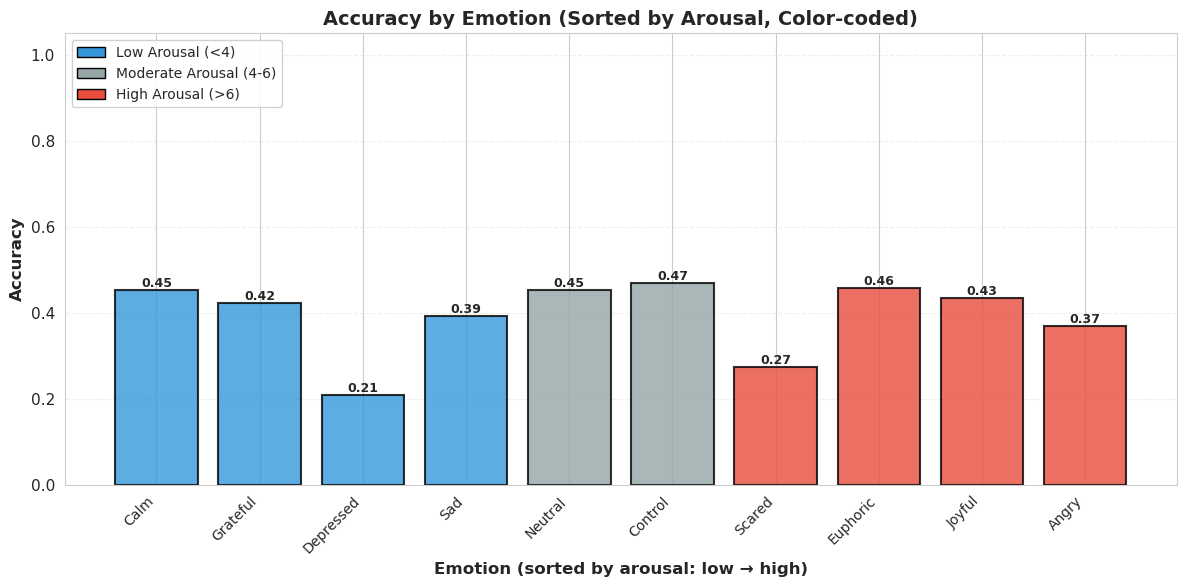


Accuracy by Emotion (sorted by arousal):
  Calm            (A=1.6)  Acc=45.2%
  Grateful        (A=1.8)  Acc=42.2%
  Depressed       (A=1.9)  Acc=20.9%
  Sad             (A=2.7)  Acc=39.1%
  Neutral         (A=4.9)  Acc=45.2%
  Control         (A=5.0)  Acc=47.0%
  Scared          (A=6.8)  Acc=27.4%
  Euphoric        (A=7.9)  Acc=45.7%
  Joyful          (A=8.0)  Acc=43.5%
  Angry           (A=8.2)  Acc=37.0%


In [ ]:
# Accuracy by Emotion (Sorted by Arousal)

from matplotlib.patches import Patch

# Emotion renaming
EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

def get_arousal_category(arousal):
    """Categorize arousal"""
    if arousal < 4:
        return 'low'
    elif arousal > 6:
        return 'high'
    else:
        return 'moderate'

# Arousal colors
AROUSAL_COLORS = {
    'low': '#3498DB',      # Blue (calm)
    'moderate': '#95A5A6',  # Gray (neutral)
    'high': '#E74C3C'       # Red (activated)
}

# Calculate accuracy by emotion
emotion_acc_arousal = df.groupby('emotion').agg({
    'answer_correctness': 'mean',
    'arousal': 'first'
}).reset_index()

emotion_acc_arousal['emotion_display'] = emotion_acc_arousal['emotion'].map(EMOTION_RENAME)
emotion_acc_arousal['arousal_category'] = emotion_acc_arousal['arousal'].apply(get_arousal_category)

# Sort by arousal (low to high)
emotion_acc_arousal = emotion_acc_arousal.sort_values('arousal')

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Get colors based on arousal
colors = [AROUSAL_COLORS[cat] for cat in emotion_acc_arousal['arousal_category']]

# Create bars
bars = ax.bar(range(len(emotion_acc_arousal)), emotion_acc_arousal['answer_correctness'],
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, emotion_acc_arousal['answer_correctness'])):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Labels: Just emotion names (no arousal numbers shown)
labels = [row['emotion_display'] for _, row in emotion_acc_arousal.iterrows()]

ax.set_xticks(range(len(emotion_acc_arousal)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor=AROUSAL_COLORS['low'], edgecolor='black', label='Low Arousal (<4)'),
    Patch(facecolor=AROUSAL_COLORS['moderate'], edgecolor='black', label='Moderate Arousal (4-6)'),
    Patch(facecolor=AROUSAL_COLORS['high'], edgecolor='black', label='High Arousal (>6)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

ax.set_xlabel('Emotion (sorted by arousal: low → high)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by Emotion (Sorted by Arousal, Color-coded)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_by_arousal_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Emotion (sorted by arousal):")
for _, row in emotion_acc_arousal.iterrows():
    print(f"  {row['emotion_display']:15} (A={row['arousal']:.1f})  Acc={row['answer_correctness']:.1%}")

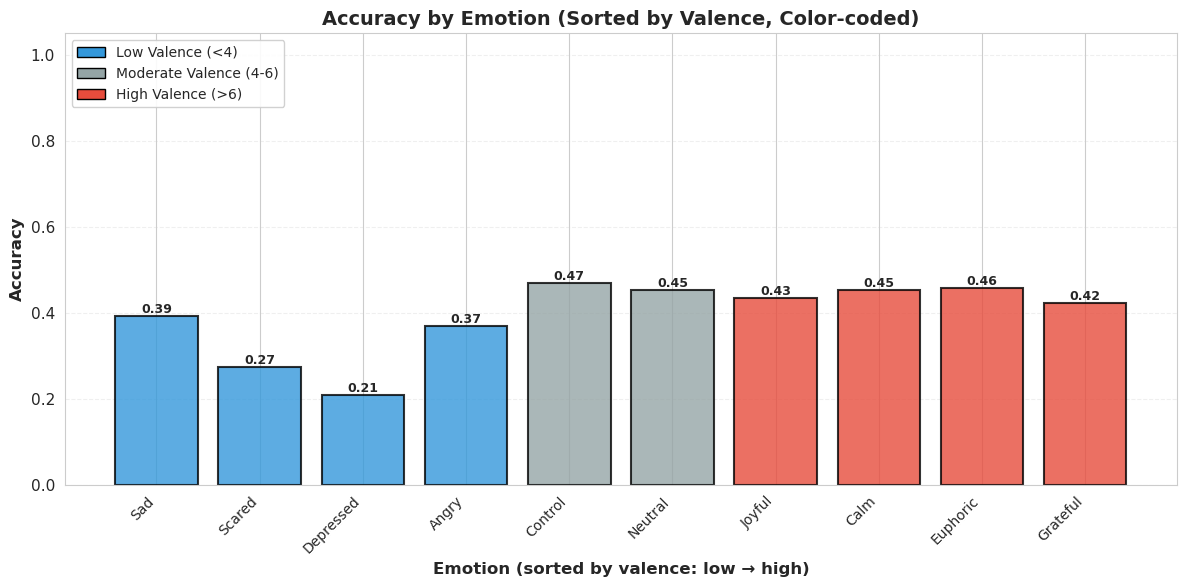


Accuracy by Emotion (sorted by valence):
  Sad             (A=1.6)  Acc=39.1%
  Scared          (A=1.7)  Acc=27.4%
  Depressed       (A=1.9)  Acc=20.9%
  Angry           (A=2.2)  Acc=37.0%
  Control         (A=5.0)  Acc=47.0%
  Neutral         (A=5.4)  Acc=45.2%
  Joyful          (A=7.7)  Acc=43.5%
  Calm            (A=8.1)  Acc=45.2%
  Euphoric        (A=8.2)  Acc=45.7%
  Grateful        (A=8.2)  Acc=42.2%


In [37]:
# Accuracy by Emotion (Sorted by Arousal)

from matplotlib.patches import Patch

# Emotion renaming
EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

def get_arousal_category(valence):
    """Categorize arousal"""
    if valence < 4:
        return 'low'
    elif valence > 6:
        return 'high'
    else:
        return 'moderate'

# Arousal colors
VALENCE_COLORS = {
    'low': '#3498DB',      # Blue (calm)
    'moderate': '#95A5A6',  # Gray (neutral)
    'high': '#E74C3C'       # Red (activated)
}

# Calculate accuracy by emotion
emotion_acc_valence = df.groupby('emotion').agg({
    'answer_correctness': 'mean',
    'valence': 'first'
}).reset_index()

emotion_acc_valence['emotion_display'] = emotion_acc_valence['emotion'].map(EMOTION_RENAME)
emotion_acc_valence['valence_category'] = emotion_acc_valence['valence'].apply(get_arousal_category)

# Sort by arousal (low to high)
emotion_acc_valence = emotion_acc_valence.sort_values('valence')

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Get colors based on arousal
colors = [AROUSAL_COLORS[cat] for cat in emotion_acc_valence['valence_category']]

# Create bars
bars = ax.bar(range(len(emotion_acc_valence)), emotion_acc_valence['answer_correctness'],
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, emotion_acc_valence['answer_correctness'])):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Labels: Just emotion names (no arousal numbers shown)
labels = [row['emotion_display'] for _, row in emotion_acc_valence.iterrows()]

ax.set_xticks(range(len(emotion_acc_valence)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor=AROUSAL_COLORS['low'], edgecolor='black', label='Low Valence (<4)'),
    Patch(facecolor=AROUSAL_COLORS['moderate'], edgecolor='black', label='Moderate Valence (4-6)'),
    Patch(facecolor=AROUSAL_COLORS['high'], edgecolor='black', label='High Valence (>6)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

ax.set_xlabel('Emotion (sorted by valence: low → high)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by Emotion (Sorted by Valence, Color-coded)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_by_arousal_sorted.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Emotion (sorted by valence):")
for _, row in emotion_acc_valence.iterrows():
    print(f"  {row['emotion_display']:15} (A={row['valence']:.1f})  Acc={row['answer_correctness']:.1%}")

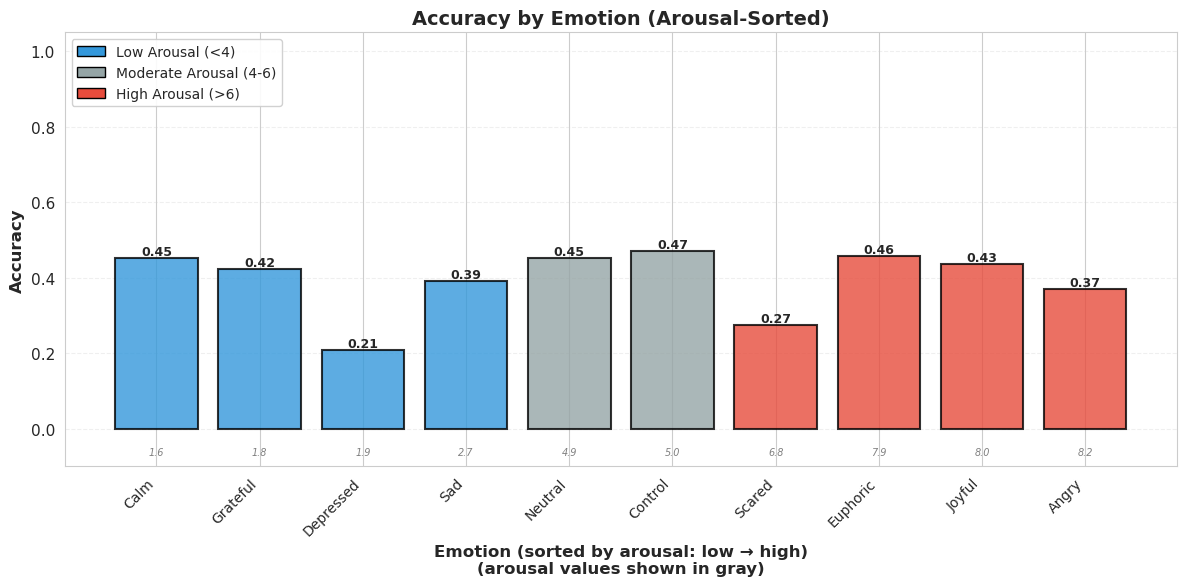

In [ ]:
# Same plot but with arousal values as subtle text below x-axis

fig, ax = plt.subplots(figsize=(12, 6))

# Get colors
colors = [AROUSAL_COLORS[cat] for cat in emotion_acc_arousal['arousal_category']]

# Create bars
bars = ax.bar(range(len(emotion_acc_arousal)), emotion_acc_arousal['answer_correctness'],
              color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, emotion_acc_arousal['answer_correctness'])):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Add arousal values as subtle text below bars
for i, (idx, row) in enumerate(emotion_acc_arousal.iterrows()):
    ax.text(i, -0.05, f'{row["arousal"]:.1f}', 
            ha='center', va='top', fontsize=7, color='gray', style='italic')

# Labels
labels = [row['emotion_display'] for _, row in emotion_acc_arousal.iterrows()]

ax.set_xticks(range(len(emotion_acc_arousal)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Legend
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

ax.set_xlabel('Emotion (sorted by arousal: low → high)\n(arousal values shown in gray)', 
              fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Accuracy by Emotion (Arousal-Sorted)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(-0.1, 1.05)  # Extra space for arousal labels

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_arousal_sorted_annotated.png', dpi=300, bbox_inches='tight')
plt.show()

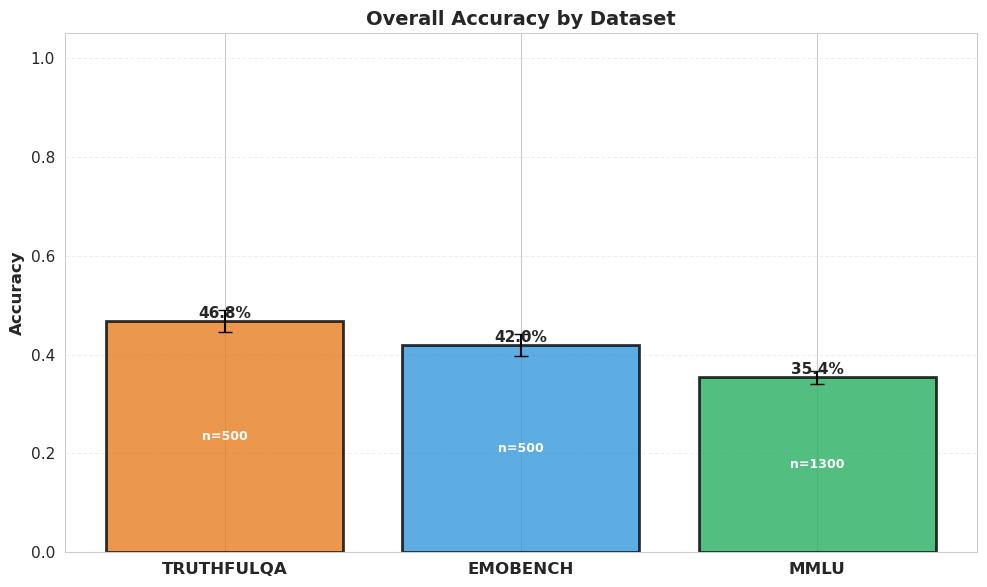


Accuracy by Dataset:
  TRUTHFULQA      46.8%  (n=500)
  EMOBENCH        42.0%  (n=500)
  MMLU            35.4%  (n=1300)


In [ ]:
# Simple bar chart: Overall accuracy by dataset

dataset_acc = df.groupby('source').agg({
    'answer_correctness': ['mean', 'sem', 'count']
}).reset_index()

dataset_acc.columns = ['source', 'accuracy', 'sem', 'count']

# Sort by accuracy
dataset_acc = dataset_acc.sort_values('accuracy', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E67E22', '#3498DB', '#27AE60']  # Orange, Blue, Green

bars = ax.bar(range(len(dataset_acc)), dataset_acc['accuracy'],
              yerr=dataset_acc['sem'], capsize=5,
              color=colors[:len(dataset_acc)], alpha=0.8,
              edgecolor='black', linewidth=2)

# Add value labels
for i, (bar, val, count) in enumerate(zip(bars, dataset_acc['accuracy'], dataset_acc['count'])):
    ax.text(i, val, f'{val:.1%}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
    ax.text(i, val/2, f'n={int(count)}', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

ax.set_xticks(range(len(dataset_acc)))
ax.set_xticklabels([s.upper() for s in dataset_acc['source']], fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Overall Accuracy by Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
# plt.savefig('../visualizations/accuracy_by_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAccuracy by Dataset:")
for _, row in dataset_acc.iterrows():
    print(f"  {row['source'].upper():15} {row['accuracy']:.1%}  (n={int(row['count'])})")